# Mapas estatales de dengue confirmado en México, 2020--2026

En los notebooks anteriores se analizaron los casos confirmados de dengue y se calcularon tasas de incidencia por 100,000 habitantes a nivel nacional, estatal y regional. Sin embargo, las tablas y gráficas de barras no siempre permiten visualizar con claridad la distribución espacial de la enfermedad.

En este notebook se construyen mapas estatales de México para representar la carga geográfica del dengue. Se ilustran tanto conteos absolutos de casos confirmados como tasas de incidencia, con énfasis en el año 2024, que fue el periodo con mayor carga nacional durante la serie analizada.

El uso de mapas permite identificar patrones espaciales, regiones de alta carga, contrastes entre estados vecinos y diferencias entre carga absoluta e incidencia relativa. Esto es importante porque un estado puede tener muchos casos simplemente por tener una población grande, mientras que otro con menos población puede presentar una incidencia mucho mayor.

Los mapas se construyen a partir de geometrías estatales en formato GeoJSON y se integran con las tablas generadas previamente de casos confirmados e incidencia.

In [3]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects
import unicodedata
import re

In [6]:
BASE = Path("datos_dengue_historicos")

DATA_DIR = BASE / "csv_unificado"
TABLE_INCIDENCIA_DIR = BASE / "tablas_incidencia"

FIG_DIR = BASE / "figuras_mapas"
TABLE_DIR = BASE / "tablas_mapas"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

DENGUE_PATH = DATA_DIR / "dengue_2020_2026.csv"
INCIDENCIA_PATH = TABLE_INCIDENCIA_DIR / "tabla_01_incidencia_estatal_anual.csv"


df = pd.read_csv(
    DENGUE_PATH,
    parse_dates=["FECHA"]
)

df = df.set_index("FECHA").sort_index()

incidencia_estado_anio = pd.read_csv(INCIDENCIA_PATH)

print("Dataset dengue:")
print(df.shape)

print("\nTabla de incidencia estatal anual:")
print(incidencia_estado_anio.shape)

incidencia_estado_anio.head()

Dataset dengue:
(242999, 8)

Tabla de incidencia estatal anual:
(224, 6)


,Unnamed: 0,ESTADO,ANIO,POBLACION,CASOS_CONFIRMADOS,INCIDENCIA_100K
0,0,AGUASCALIENTES,2020,1456050,4,0.274716
1,1,BAJA CALIFORNIA,2020,3838619,5,0.130255
2,2,BAJA CALIFORNIA SUR,2020,815098,30,3.680539
3,3,CAMPECHE,2020,939179,40,4.259039
4,4,CHIAPAS,2020,5715260,318,5.564051


In [8]:
# Celda 2. Cargar GeoJSON estatal y homologar nombres


url = "https://raw.githubusercontent.com/strotgen/mexico-leaflet/refs/heads/master/states.geojson"

gdf = gpd.read_file(url)

print("Columnas del GeoDataFrame:")
print(gdf.columns.tolist())

print("\nNombres originales en el GeoJSON:")
print(gdf[["state_name"]].sort_values("state_name").reset_index(drop=True))


def quitar_acentos_mayusculas(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).strip().upper()
    texto = unicodedata.normalize("NFD", texto)
    texto = "".join(
        c for c in texto 
        if unicodedata.category(c) != "Mn"
    )
    texto = re.sub(r"\s+", " ", texto)
    
    return texto


def homologar_estado_geojson(texto):
    texto = quitar_acentos_mayusculas(texto)
    
    reemplazos = {
        "CIUDAD DE MEXICO": "DISTRITO FEDERAL",
        "DISTRITO FEDERAL": "DISTRITO FEDERAL",
        "MEXICO": "MEXICO",
        "COAHUILA DE ZARAGOZA": "COAHUILA",
        "MICHOACAN DE OCAMPO": "MICHOACAN",
        "VERACRUZ DE IGNACIO DE LA LLAVE": "VERACRUZ",
        "QUERETARO": "QUERETARO",
        "SAN LUIS POTOSI": "SAN LUIS POTOSI",
        "NUEVO LEON": "NUEVO LEON",
        "YUCATAN": "YUCATAN",
    }
    
    return reemplazos.get(texto, texto)


gdf["ESTADO"] = gdf["state_name"].apply(homologar_estado_geojson)

print("\nNombres homologados:")
print(gdf[["state_name", "ESTADO"]].sort_values("ESTADO").reset_index(drop=True))

# ------------------------------------------------------------
# Verificar coincidencia con dengue
# ------------------------------------------------------------

estados_geo = set(gdf["ESTADO"].unique())
estados_dengue = set(df["ESTADO"].unique())

print("\nEstados en dengue que no están en GeoJSON:")
print(sorted(estados_dengue - estados_geo))

print("\nEstados en GeoJSON que no están en dengue:")
print(sorted(estados_geo - estados_dengue))

Columnas del GeoDataFrame:
['id', 'state_code', 'state_name', 'geometry']

Nombres originales en el GeoJSON:
                         state_name
0                    Aguascalientes
1                   Baja California
2               Baja California Sur
3                          Campeche
4                           Chiapas
5                         Chihuahua
6              Coahuila de Zaragoza
7                            Colima
8                  Distrito Federal
9                           Durango
10                       Guanajuato
11                         Guerrero
12                          Hidalgo
13                          Jalisco
14              Michoacán de Ocampo
15                          Morelos
16                           México
17                          Nayarit
18                       Nuevo León
19                           Oaxaca
20                           Puebla
21                        Querétaro
22                     Quintana Roo
23                  San Lui

In [16]:
# ============================================================
# Celda 3. Mapa estatal de incidencia de dengue confirmado en 2024
# ============================================================

# ------------------------------------------------------------
# 1. Preparar datos de incidencia 2024
# ------------------------------------------------------------

mapa_incidencia_2024 = (
    incidencia_estado_anio
    .query("ANIO == 2024")
    .copy()
)

# Unir geometría con tabla de incidencia
gdf_incidencia_2024 = gdf.merge(
    mapa_incidencia_2024,
    on="ESTADO",
    how="left"
)

print("Valores faltantes después del cruce:")
print(gdf_incidencia_2024[["ESTADO", "CASOS_CONFIRMADOS", "POBLACION", "INCIDENCIA_100K"]].isna().sum())

print("\nTop 10 estados por incidencia en 2024:")
print(
    gdf_incidencia_2024[
        ["ESTADO", "CASOS_CONFIRMADOS", "POBLACION", "INCIDENCIA_100K"]
    ]
    .sort_values("INCIDENCIA_100K", ascending=False)
    .head(10)
    .round({"INCIDENCIA_100K": 1})
)

# ------------------------------------------------------------
# 2. Abreviaturas para etiquetas
# ------------------------------------------------------------

abreviaturas = {
    "AGUASCALIENTES": "AGS",
    "BAJA CALIFORNIA": "BC",
    "BAJA CALIFORNIA SUR": "BCS",
    "CAMPECHE": "CAM",
    "CHIAPAS": "CHIS",
    "CHIHUAHUA": "CHIH",
    "COAHUILA": "COAH",
    "COLIMA": "COL",
    "DISTRITO FEDERAL": "CDMX",
    "DURANGO": "DGO",
    "GUANAJUATO": "GTO",
    "GUERRERO": "GRO",
    "HIDALGO": "HGO",
    "JALISCO": "JAL",
    "MEXICO": "MEX",
    "MICHOACAN": "MICH",
    "MORELOS": "MOR",
    "NAYARIT": "NAY",
    "NUEVO LEON": "NL",
    "OAXACA": "OAX",
    "PUEBLA": "PUE",
    "QUERETARO": "QRO",
    "QUINTANA ROO": "QROO",
    "SAN LUIS POTOSI": "SLP",
    "SINALOA": "SIN",
    "SONORA": "SON",
    "TABASCO": "TAB",
    "TAMAULIPAS": "TAM",
    "TLAXCALA": "TLAX",
    "VERACRUZ": "VER",
    "YUCATAN": "YUC",
    "ZACATECAS": "ZAC",
}

gdf_incidencia_2024["ABREV"] = gdf_incidencia_2024["ESTADO"].map(abreviaturas)
gdf_incidencia_2024["label_pt"] = gdf_incidencia_2024.geometry.representative_point()



Valores faltantes después del cruce:
ESTADO               0
CASOS_CONFIRMADOS    0
POBLACION            0
INCIDENCIA_100K      0
dtype: int64

Top 10 estados por incidencia en 2024:
                 ESTADO  CASOS_CONFIRMADOS  POBLACION  INCIDENCIA_100K
11               COLIMA               5043     762387            661.5
12              NAYARIT               5490    1309432            419.3
3               MORELOS               6343    2043884            310.3
7   BAJA CALIFORNIA SUR               2569     886050            289.9
14              JALISCO              20419    8820915            231.5
19       AGUASCALIENTES               3205    1530185            209.5
1              GUERRERO               6589    3606733            182.7
26           NUEVO LEON              10544    6308199            167.1
27             COAHUILA               5584    3358991            166.2
4               SINALOA               4672    3165686            147.6


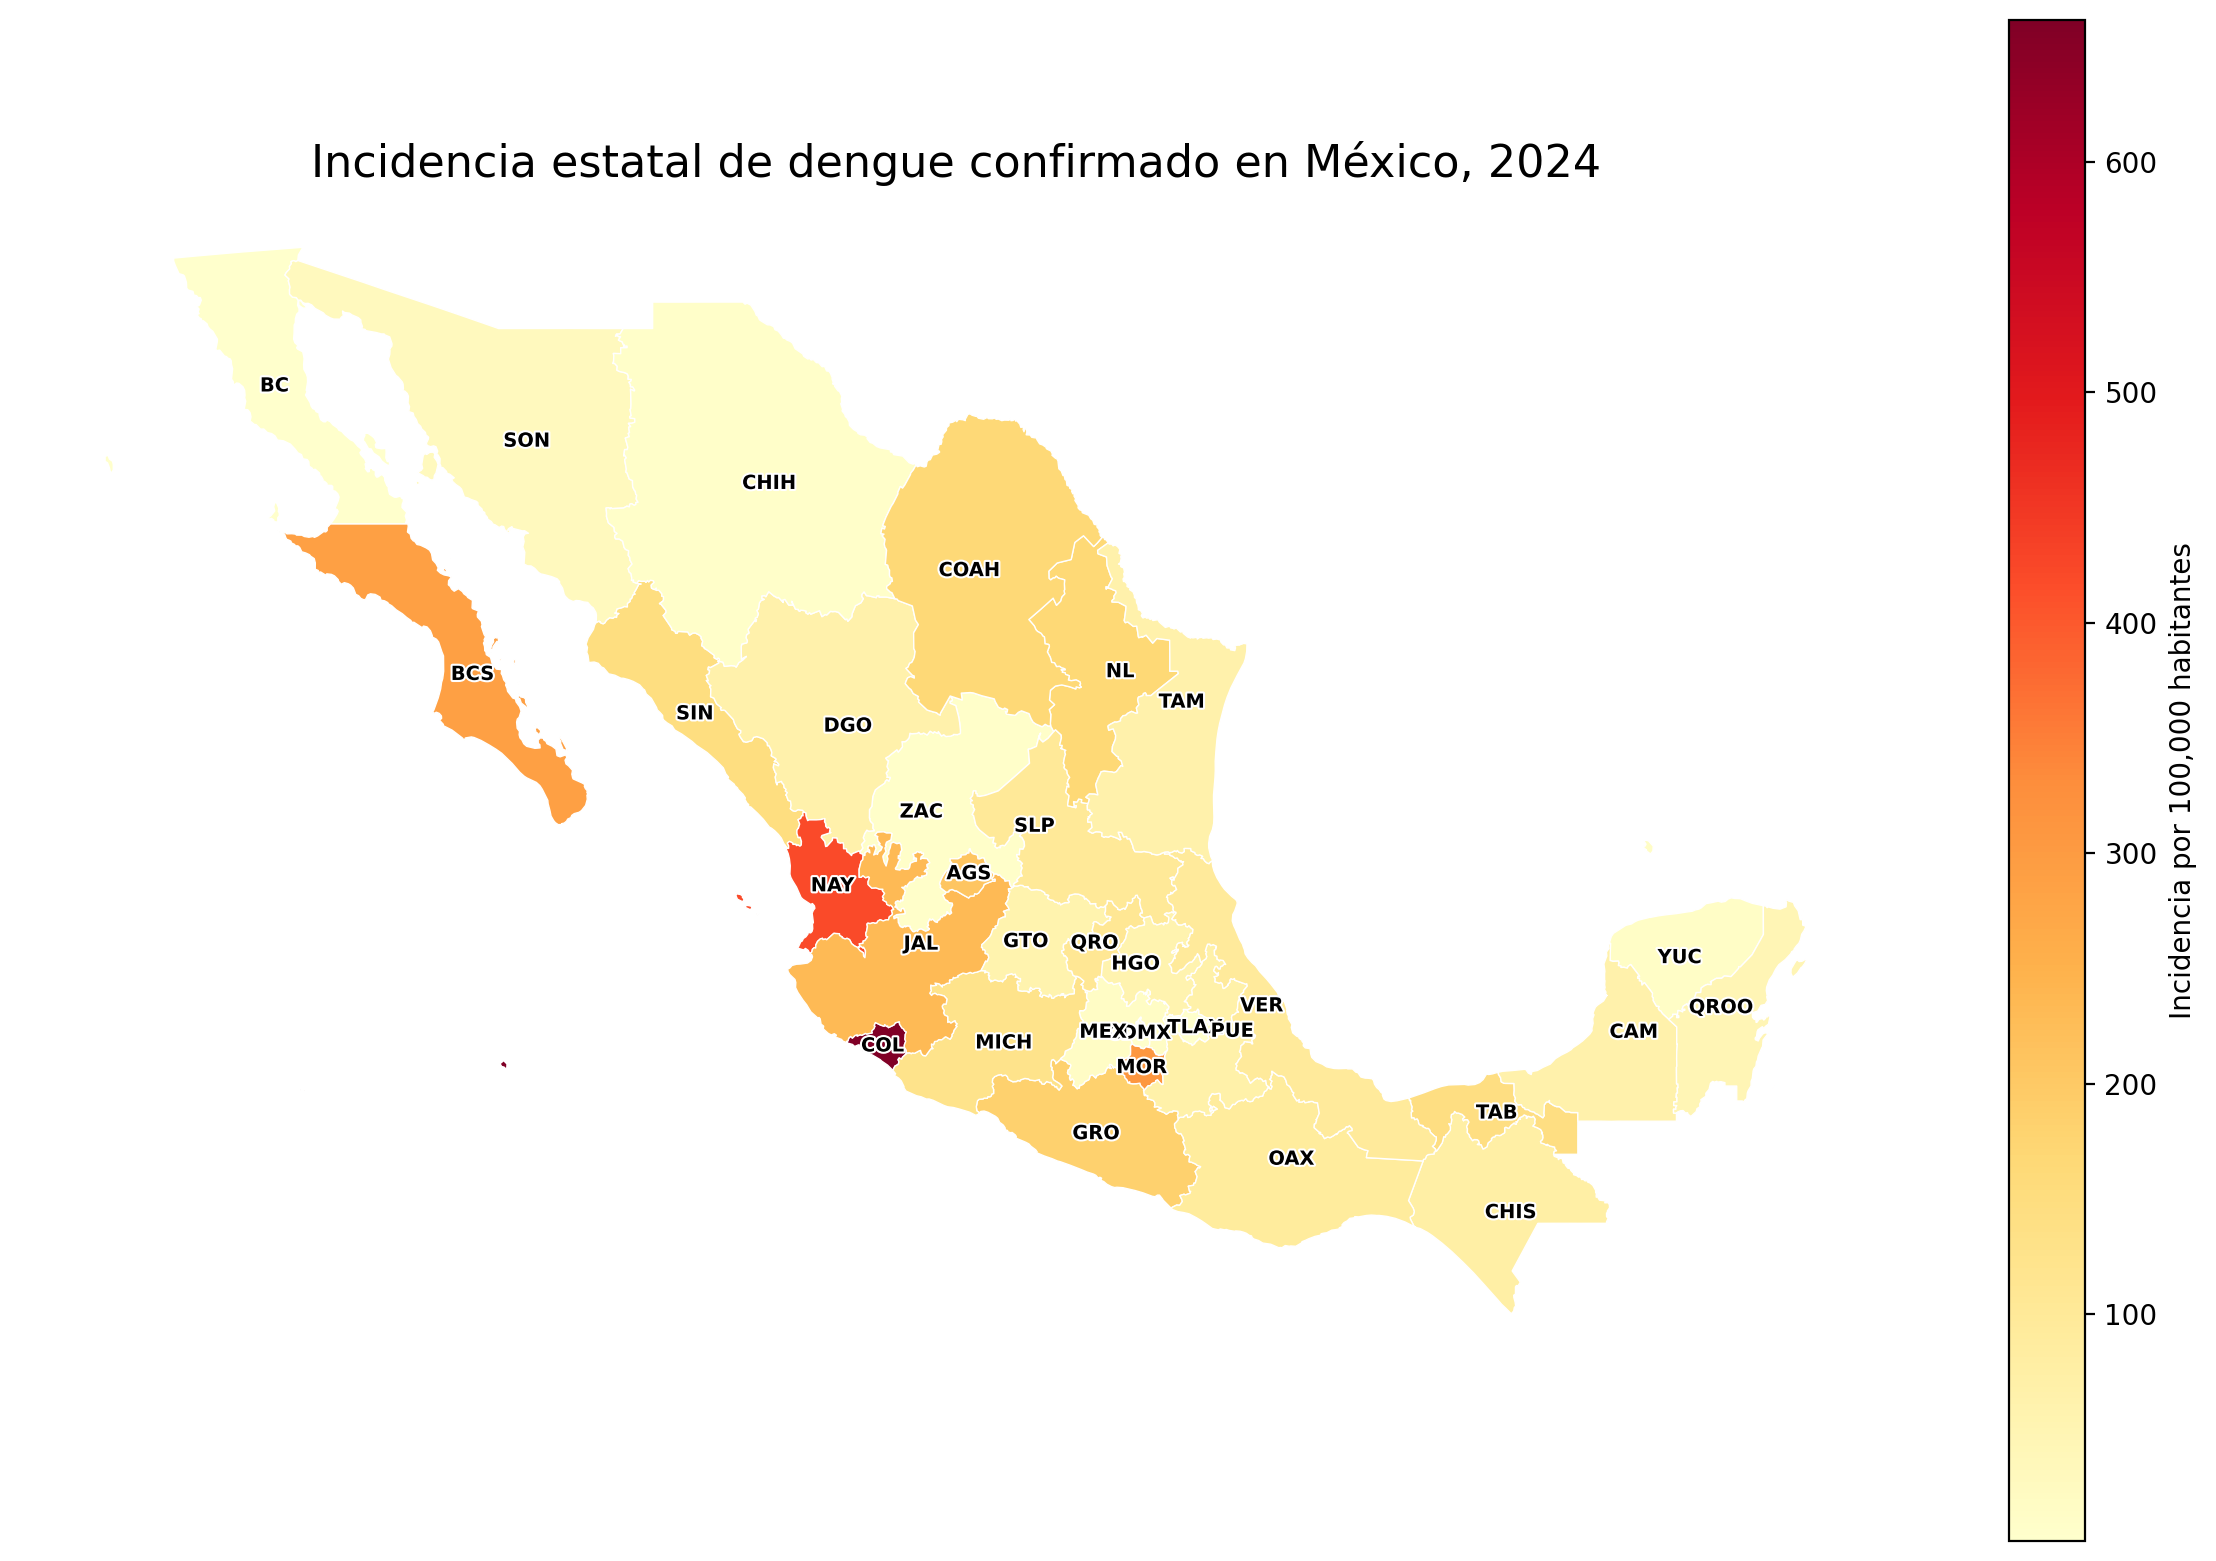

In [15]:
fig, ax = plt.subplots(figsize=(12, 12), dpi=200)

gdf_incidencia_2024.plot(
    column="INCIDENCIA_100K",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "label": "Incidencia por 100,000 habitantes",
        "shrink": 0.65
    },
    ax=ax
)

# Etiquetas con abreviaturas
for _, row in gdf_incidencia_2024.iterrows():
    x, y = row["label_pt"].x, row["label_pt"].y
    ax.text(
        x,
        y,
        row["ABREV"],
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
        path_effects=[
            patheffects.withStroke(linewidth=1.5, foreground="white")
        ]
    )

ax.set_title(
    "Incidencia estatal de dengue confirmado en México, 2024",
    fontsize=16
)

ax.axis("off")

plt.tight_layout()
plt.show()

# Guardar tabla 
gdf_incidencia_2024.drop(columns="geometry").to_csv(
    TABLE_DIR / "tabla_01_mapa_incidencia_estatal_2024.csv",
    index=False,
    encoding="utf-8"
)

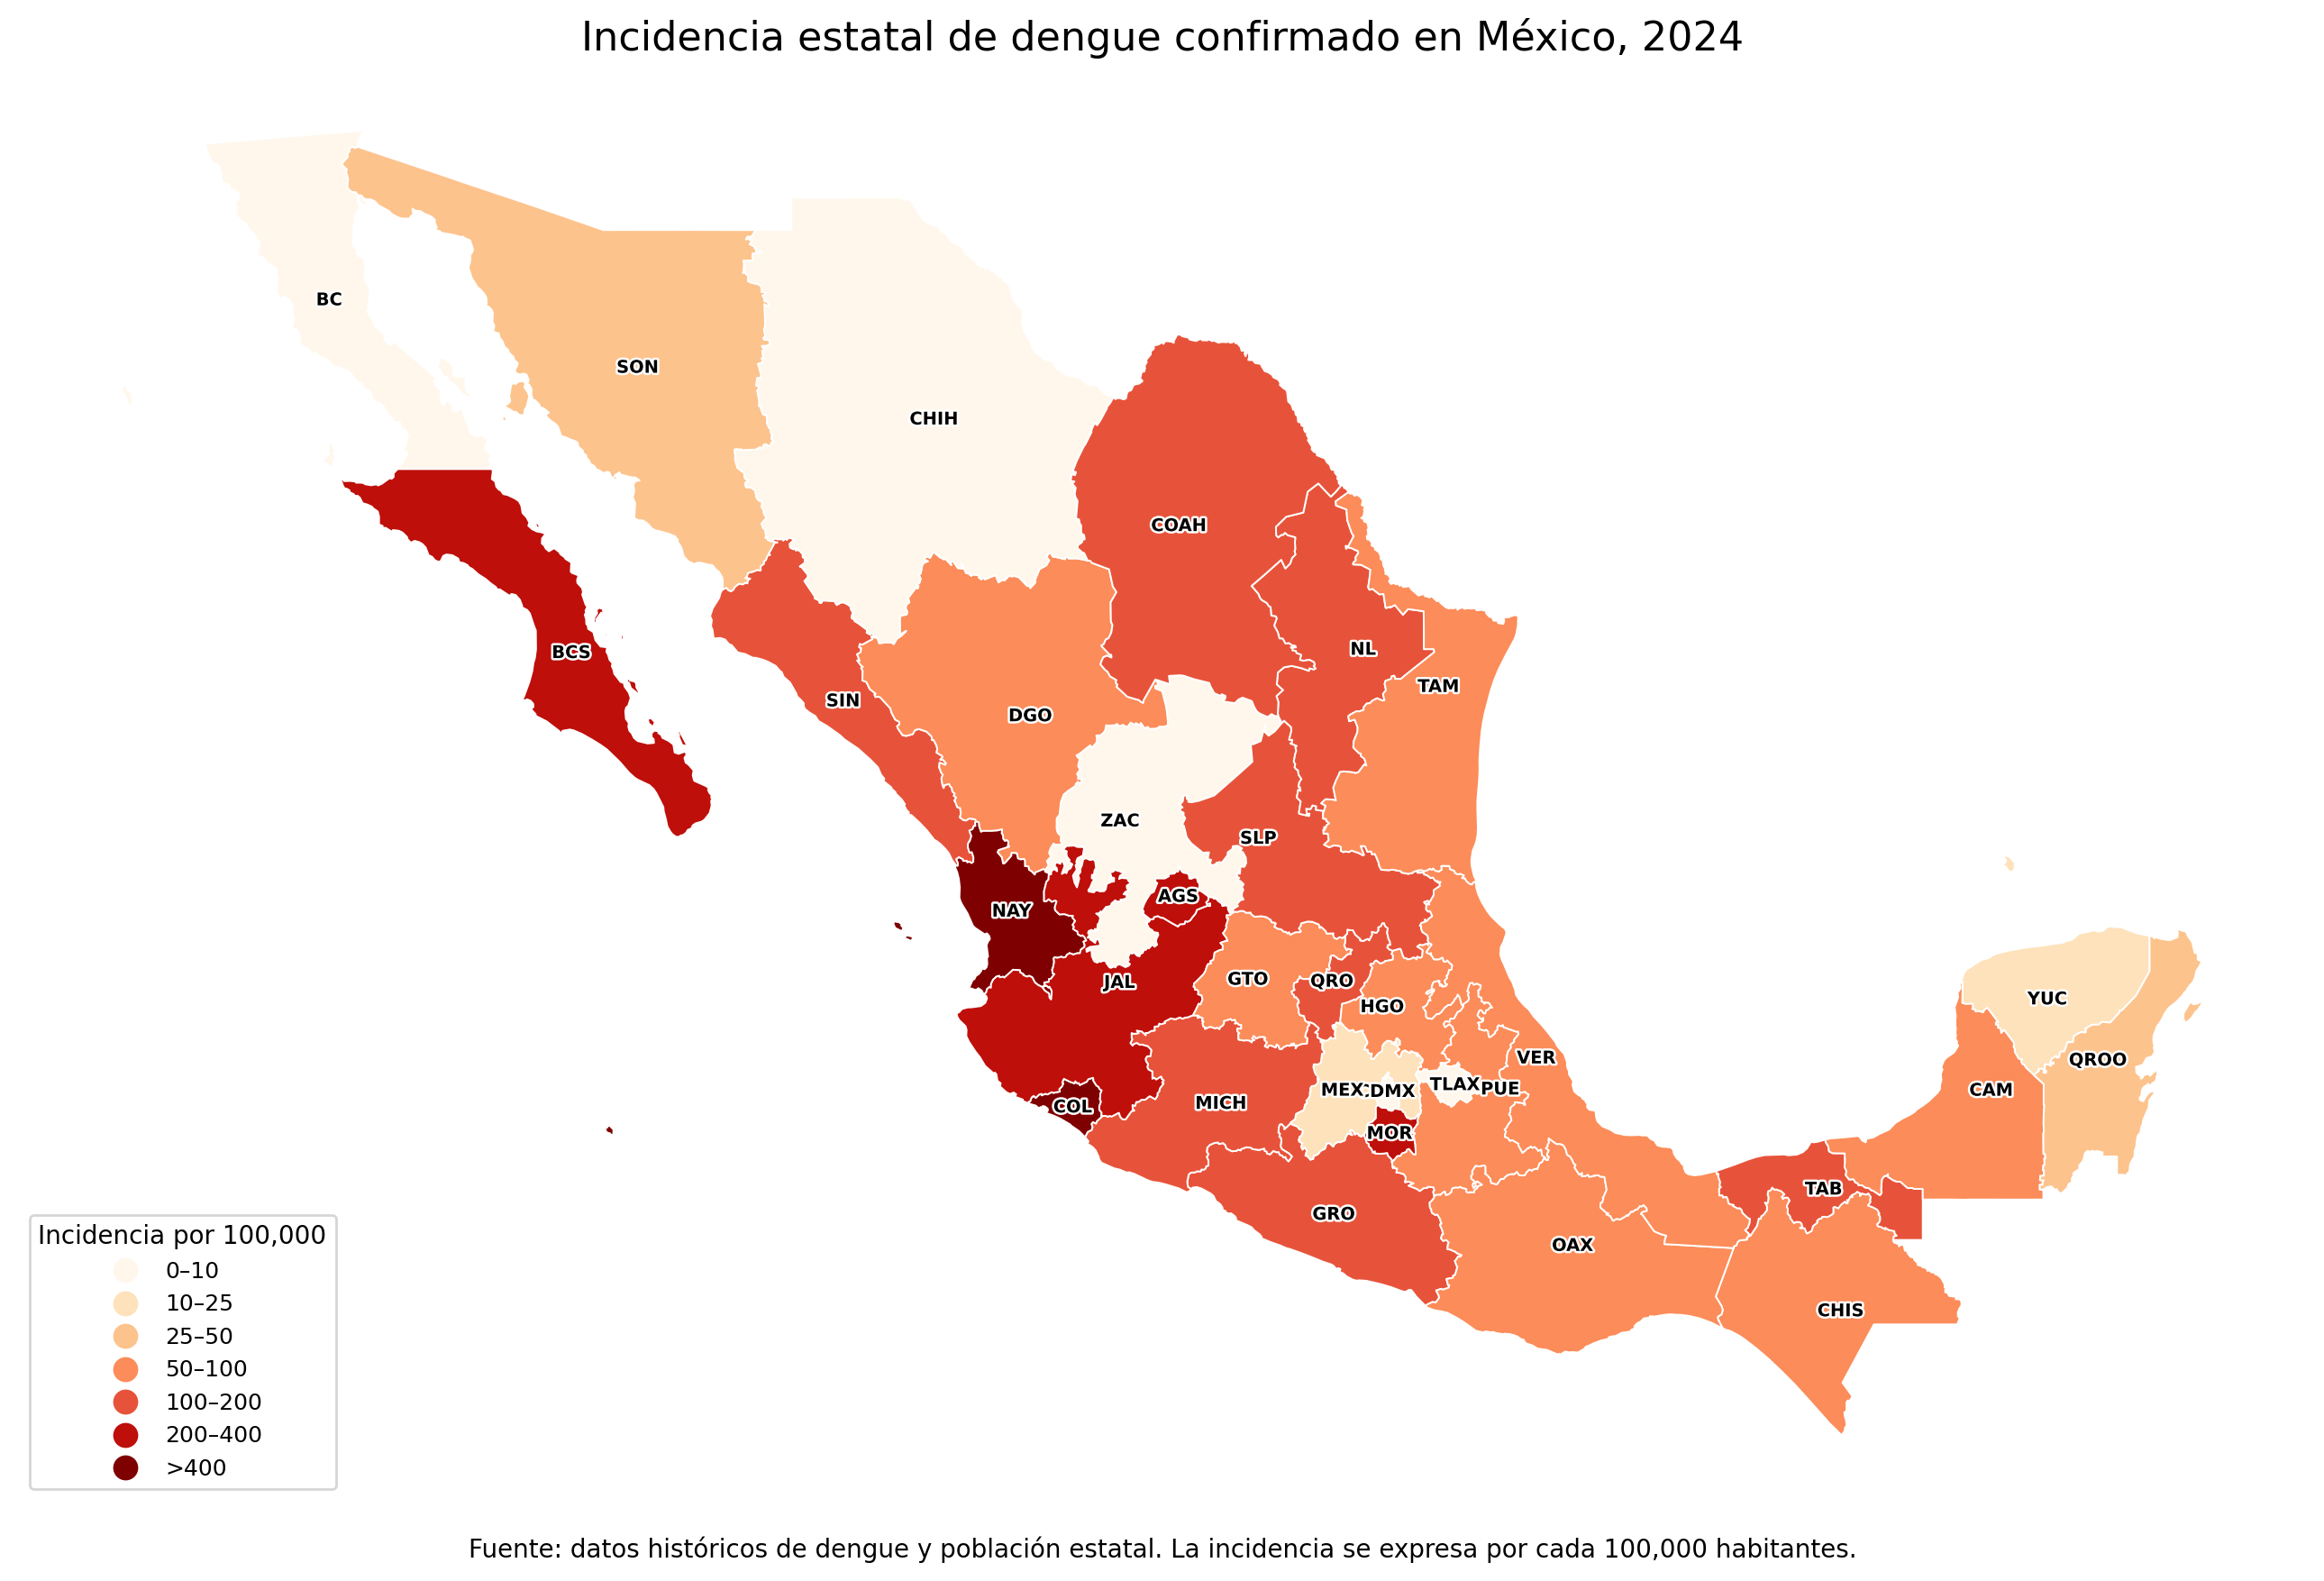

In [20]:
gdf_plot = gdf_incidencia_2024.copy()

# Clases de incidencia
bins = [0, 10, 25, 50, 100, 200, 400, 700]
labels = ["0–10", "10–25", "25–50", "50–100", "100–200", "200–400", ">400"]

gdf_plot["CLASE_INCIDENCIA"] = pd.cut(
    gdf_plot["INCIDENCIA_100K"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

fig, ax = plt.subplots(figsize=(13, 10), dpi=200)

gdf_plot.plot(
    column="CLASE_INCIDENCIA",
    categorical=True,
    cmap="OrRd",
    linewidth=0.7,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "title": "Incidencia por 100,000",
        "loc": "lower left",
        "fontsize": 9,
        "title_fontsize": 10
    },
    ax=ax
)

# Etiquetas abreviadas
for _, row in gdf_plot.iterrows():
    x, y = row["label_pt"].x, row["label_pt"].y
    ax.text(
        x, y, row["ABREV"],
        ha="center", va="center",
        fontsize=7, fontweight="bold", color="black",
        path_effects=[patheffects.withStroke(linewidth=1.8, foreground="white")]
    )

ax.set_title("Incidencia estatal de dengue confirmado en México, 2024", fontsize=16)
ax.text(
    0.5, -0.04,
    "Fuente: datos históricos de dengue y población estatal. "
    "La incidencia se expresa por cada 100,000 habitantes.",
    transform=ax.transAxes,
    ha="center", fontsize=10
)
ax.axis("off")

fig_path = FIG_DIR / "fig_01_mapa_incidencia_estatal_dengue_2024.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# Celda 4. Mapa estatal de casos confirmados de dengue en 2024
# ============================================================

# ------------------------------------------------------------
# 1. Preparar datos de casos 2024
# ------------------------------------------------------------

mapa_casos_2024 = (
    incidencia_estado_anio
    .query("ANIO == 2024")
    .copy()
)

gdf_casos_2024 = gdf.merge(
    mapa_casos_2024,
    on="ESTADO",
    how="left"
)

gdf_casos_2024["ABREV"] = gdf_casos_2024["ESTADO"].map(abreviaturas)
gdf_casos_2024["label_pt"] = gdf_casos_2024.geometry.representative_point()

print("Valores faltantes después del cruce:")
print(
    gdf_casos_2024[
        ["ESTADO", "CASOS_CONFIRMADOS", "POBLACION", "INCIDENCIA_100K"]
    ].isna().sum()
)

print("\nTop 10 estados por casos confirmados en 2024:")
print(
    gdf_casos_2024[
        ["ESTADO", "CASOS_CONFIRMADOS", "POBLACION", "INCIDENCIA_100K"]
    ]
    .sort_values("CASOS_CONFIRMADOS", ascending=False)
    .head(10)
    .round({"INCIDENCIA_100K": 1})
)

# ------------------------------------------------------------
# 2. Clases de casos confirmados
# ------------------------------------------------------------

bins = [0, 250, 500, 1000, 2500, 5000, 10000, 25000]
labels = [
    "0–250",
    "250–500",
    "500–1,000",
    "1,000–2,500",
    "2,500–5,000",
    "5,000–10,000",
    ">10,000"
]

gdf_casos_2024["CLASE_CASOS"] = pd.cut(
    gdf_casos_2024["CASOS_CONFIRMADOS"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

Valores faltantes después del cruce:
ESTADO               0
CASOS_CONFIRMADOS    0
POBLACION            0
INCIDENCIA_100K      0
dtype: int64

Top 10 estados por casos confirmados en 2024:
        ESTADO  CASOS_CONFIRMADOS  POBLACION  INCIDENCIA_100K
14     JALISCO              20419    8820915            231.5
26  NUEVO LEON              10544    6308199            167.1
25    VERACRUZ               7888    8127727             97.1
1     GUERRERO               6589    3606733            182.7
13   MICHOACAN               6395    4998654            127.9
3      MORELOS               6343    2043884            310.3
27    COAHUILA               5584    3358991            166.2
12     NAYARIT               5490    1309432            419.3
11      COLIMA               5043     762387            661.5
23      PUEBLA               4748    6989402             67.9


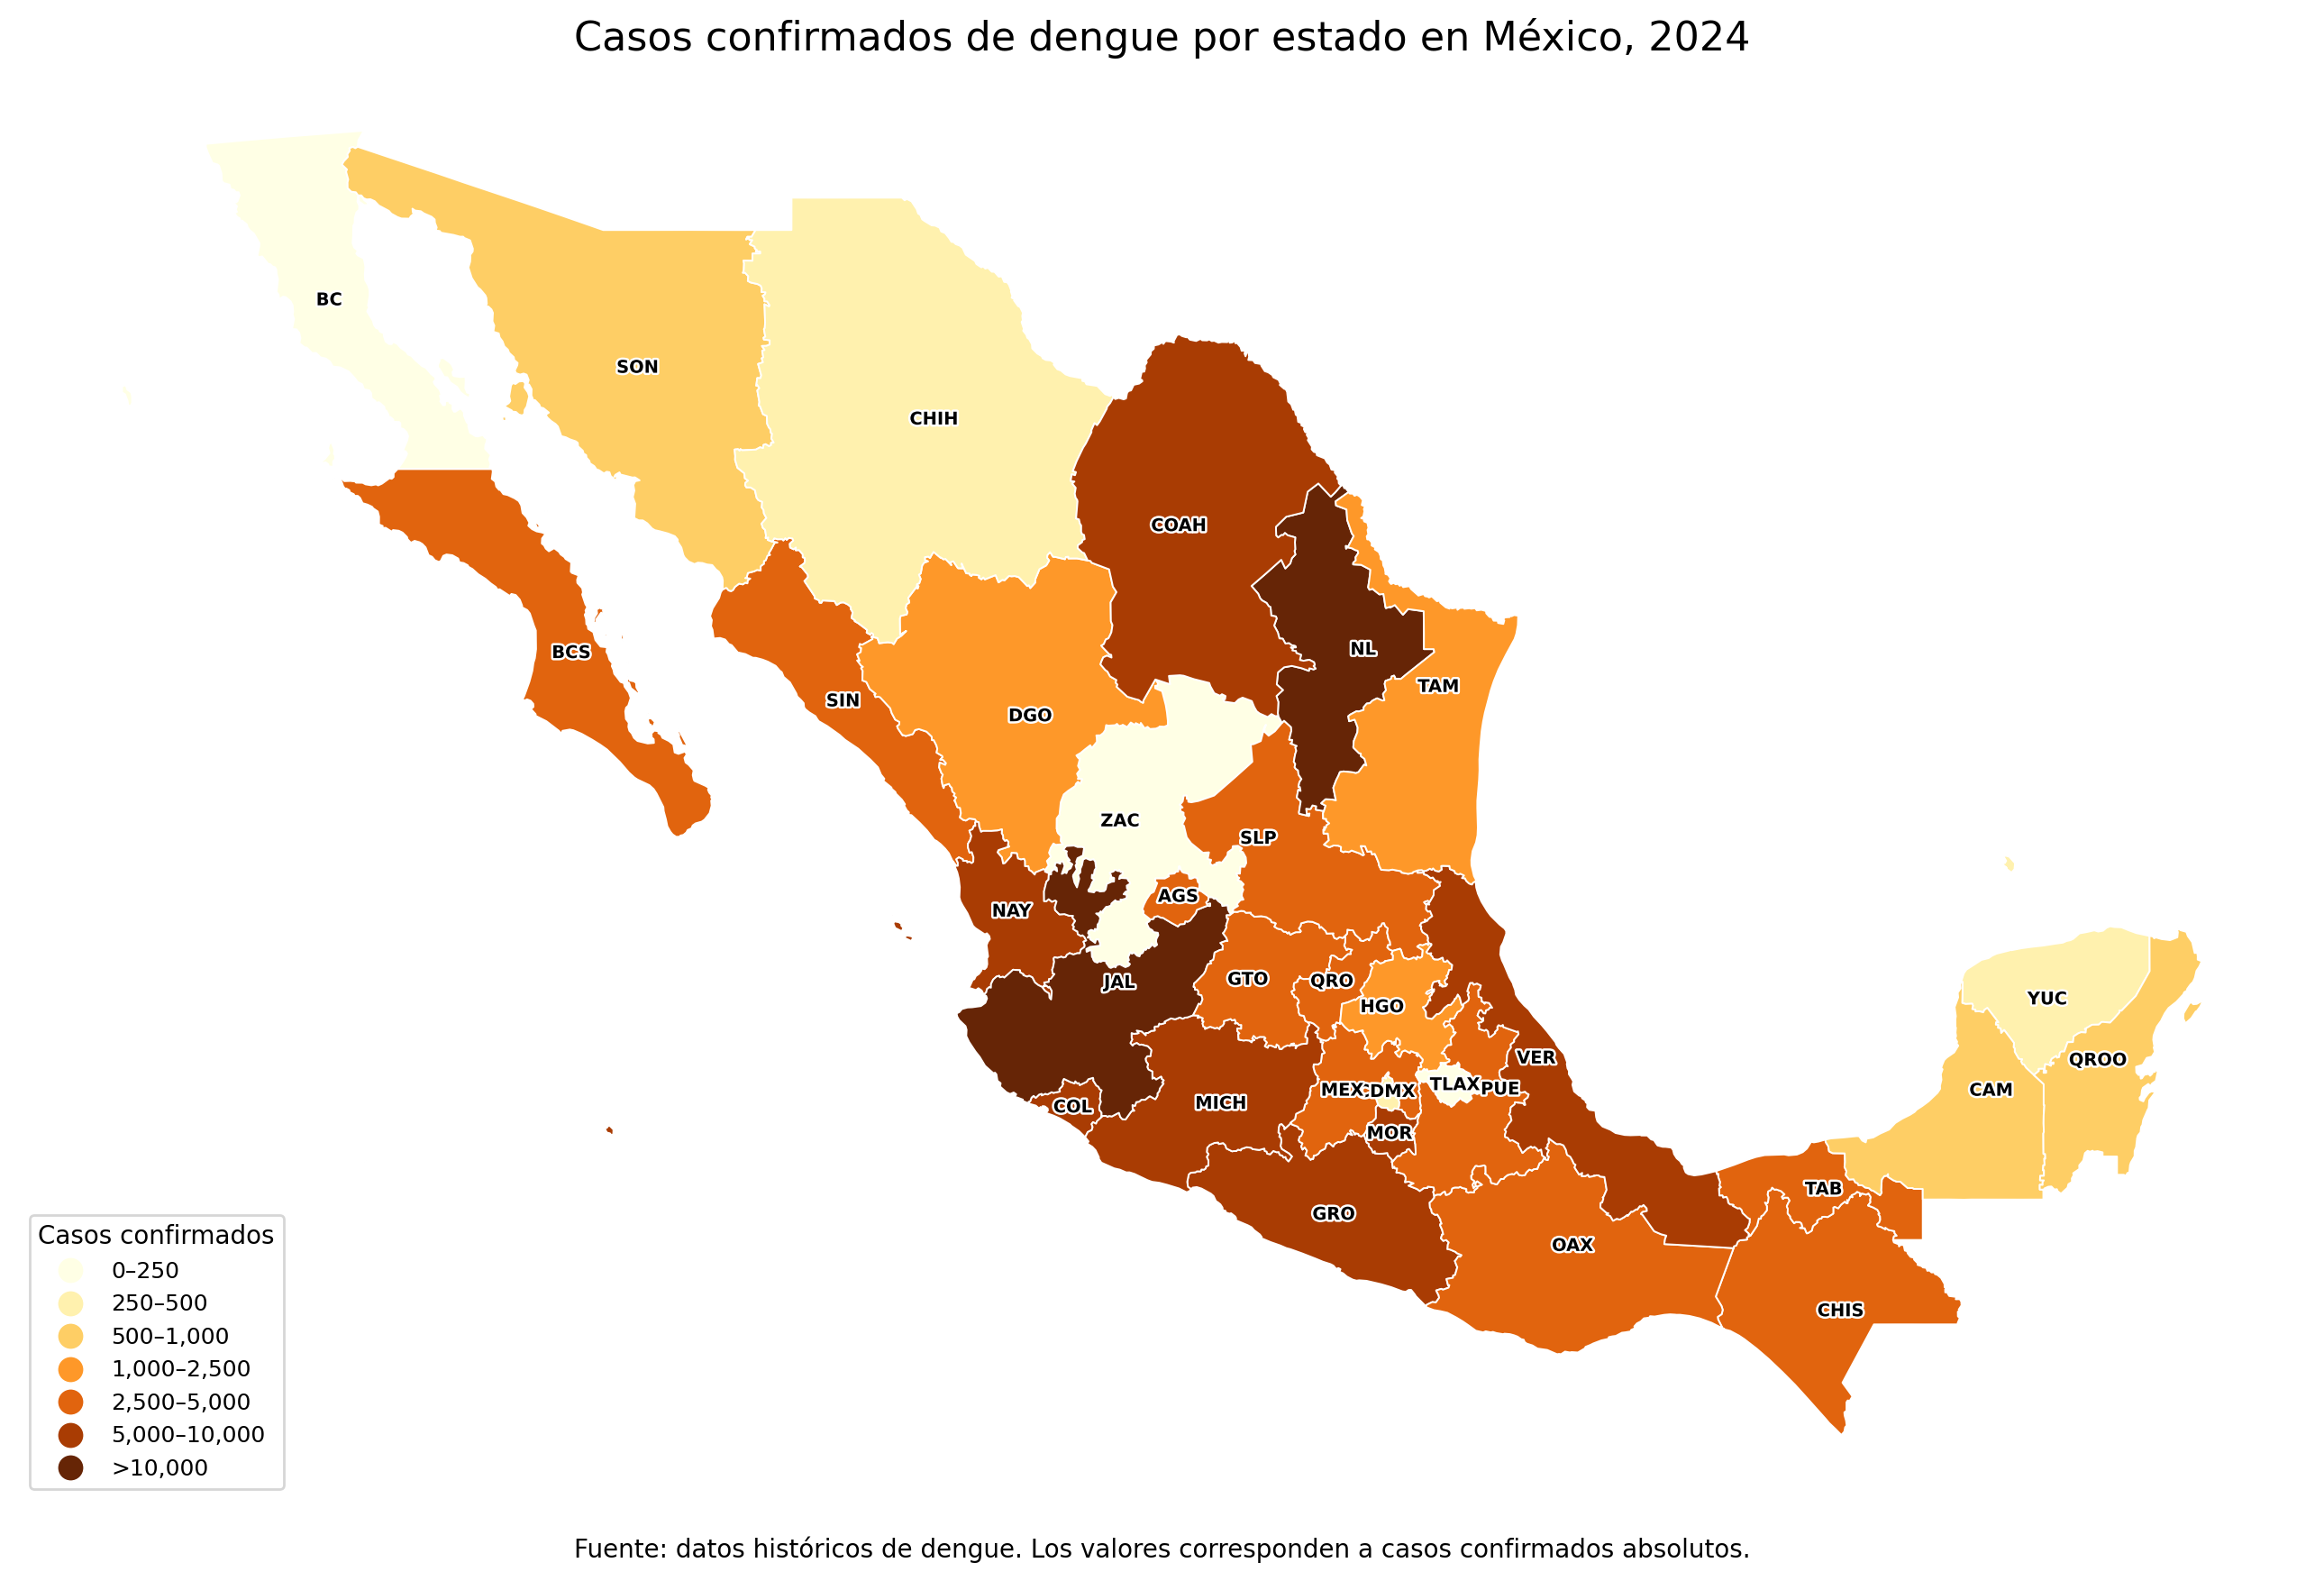

Figura guardada en: datos_dengue_historicos/figuras_mapas/fig_02_mapa_casos_confirmados_estatal_dengue_2024.png


In [25]:
# ------------------------------------------------------------
# 3. Mapa
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 10), dpi=200)

gdf_casos_2024.plot(
    column="CLASE_CASOS",
    categorical=True,
    cmap="YlOrBr",
    linewidth=0.7,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "title": "Casos confirmados",
        "loc": "lower left",
        "fontsize": 9,
        "title_fontsize": 10
    },
    ax=ax
)

# Etiquetas abreviadas
for _, row in gdf_casos_2024.iterrows():
    x, y = row["label_pt"].x, row["label_pt"].y
    ax.text(
        x,
        y,
        row["ABREV"],
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
        color="black",
        path_effects=[
            patheffects.withStroke(linewidth=1.8, foreground="white")
        ]
    )

ax.set_title(
    "Casos confirmados de dengue por estado en México, 2024",
    fontsize=16
)

ax.text(
    0.5,
    -0.04,
    "Fuente: datos históricos de dengue. Los valores corresponden a casos confirmados absolutos.",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.axis("off")

plt.tight_layout()

fig_path = FIG_DIR / "fig_02_mapa_casos_confirmados_estatal_dengue_2024.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

# 4. Guardar tabla usada en el mapa


gdf_casos_2024.drop(
    columns=["geometry", "label_pt"],
    errors="ignore"
).to_csv(
    TABLE_DIR / "tabla_02_mapa_casos_confirmados_estatal_2024.csv",
    index=False,
    encoding="utf-8"
)


Por casos absolutos en 2024 destacan:
Jalisco, Nuevo León, Veracruz, Guerrero, Michoacán, Morelos, Coahuila, Nayarit y Colima.

Por incidencia destacan:
Colima, Nayarit, Morelos, Baja California Sur, Jalisco y Aguascalientes.

In [29]:
# ============================================================
# Celda 5. Mapa regional de incidencia de dengue confirmado en 2024
# ============================================================

# ------------------------------------------------------------
# 1. Definir regiones usando nombres homologados
# ------------------------------------------------------------

region_map_homologado = {
    # Región 1
    "BAJA CALIFORNIA": "Región 1",
    "BAJA CALIFORNIA SUR": "Región 1",
    "SINALOA": "Región 1",
    "SONORA": "Región 1",

    # Región 2
    "CHIHUAHUA": "Región 2",
    "DURANGO": "Región 2",
    "ZACATECAS": "Región 2",

    # Región 3
    "COAHUILA": "Región 3",
    "NUEVO LEON": "Región 3",
    "SAN LUIS POTOSI": "Región 3",
    "TAMAULIPAS": "Región 3",

    # Región 4
    "COLIMA": "Región 4",
    "JALISCO": "Región 4",
    "MICHOACAN": "Región 4",
    "NAYARIT": "Región 4",

    # Región 5
    "CHIAPAS": "Región 5",
    "GUERRERO": "Región 5",
    "OAXACA": "Región 5",
    "VERACRUZ": "Región 5",

    # Región 6
    "CAMPECHE": "Región 6",
    "QUINTANA ROO": "Región 6",
    "TABASCO": "Región 6",
    "YUCATAN": "Región 6",

    # Región 7
    "DISTRITO FEDERAL": "Región 7",
    "MEXICO": "Región 7",
    "MORELOS": "Región 7",
    "PUEBLA": "Región 7",
    "TLAXCALA": "Región 7",

    # Región 8
    "AGUASCALIENTES": "Región 8",
    "GUANAJUATO": "Región 8",
    "HIDALGO": "Región 8",
    "QUERETARO": "Región 8",
}

gdf_region = gdf.copy()
gdf_region["REGION"] = gdf_region["ESTADO"].map(region_map_homologado)

print("Estados sin región asignada:")
display(gdf_region[gdf_region["REGION"].isna()][["state_name", "ESTADO"]])

# ------------------------------------------------------------
# 2. Calcular incidencia regional en 2024
# ------------------------------------------------------------

incidencia_region_2024 = (
    incidencia_estado_anio
    .query("ANIO == 2024")
    .assign(REGION=lambda x: x["ESTADO"].map(region_map_homologado))
    .groupby("REGION", as_index=False)
    .agg(
        CASOS_CONFIRMADOS=("CASOS_CONFIRMADOS", "sum"),
        POBLACION=("POBLACION", "sum")
    )
)

incidencia_region_2024["INCIDENCIA_REGION_100K"] = (
    incidencia_region_2024["CASOS_CONFIRMADOS"]
    / incidencia_region_2024["POBLACION"]
    * 100_000
)

incidencia_region_2024 = incidencia_region_2024.sort_values(
    "INCIDENCIA_REGION_100K",
    ascending=False
)

print("Incidencia regional en 2024:")
print(incidencia_region_2024.round({"INCIDENCIA_REGION_100K": 2}))

# ------------------------------------------------------------
# 3. Unir incidencia regional al mapa estatal
# ------------------------------------------------------------

gdf_region_2024 = gdf_region.merge(
    incidencia_region_2024,
    on="REGION",
    how="left"
)

gdf_region_2024["ABREV"] = gdf_region_2024["ESTADO"].map(abreviaturas)
gdf_region_2024["label_pt"] = gdf_region_2024.geometry.representative_point()

# ------------------------------------------------------------
# 4. Clases de incidencia regional
# ------------------------------------------------------------

bins = [0, 25, 50, 75, 100, 150, 200, 300]
labels = ["0–25", "25–50", "50–75", "75–100", "100–150", "150–200", ">200"]

gdf_region_2024["CLASE_INCIDENCIA_REGIONAL"] = pd.cut(
    gdf_region_2024["INCIDENCIA_REGION_100K"],
    bins=bins,
    labels=labels,
    include_lowest=True
)



Estados sin región asignada:


,state_name,ESTADO


Incidencia regional en 2024:
     REGION  CASOS_CONFIRMADOS  POBLACION  INCIDENCIA_REGION_100K
3  Región 4              37347   15891388                  235.01
2  Región 3              21558   16340649                  131.93
4  Región 5              22847   22071157                  103.52
7  Región 8              11864   13882816                   85.46
0  Región 1               8285   11235312                   73.74
5  Región 6               5497    7960745                   69.05
6  Región 7              14055   37283819                   37.70
1  Región 2               1687    7608530                   22.17


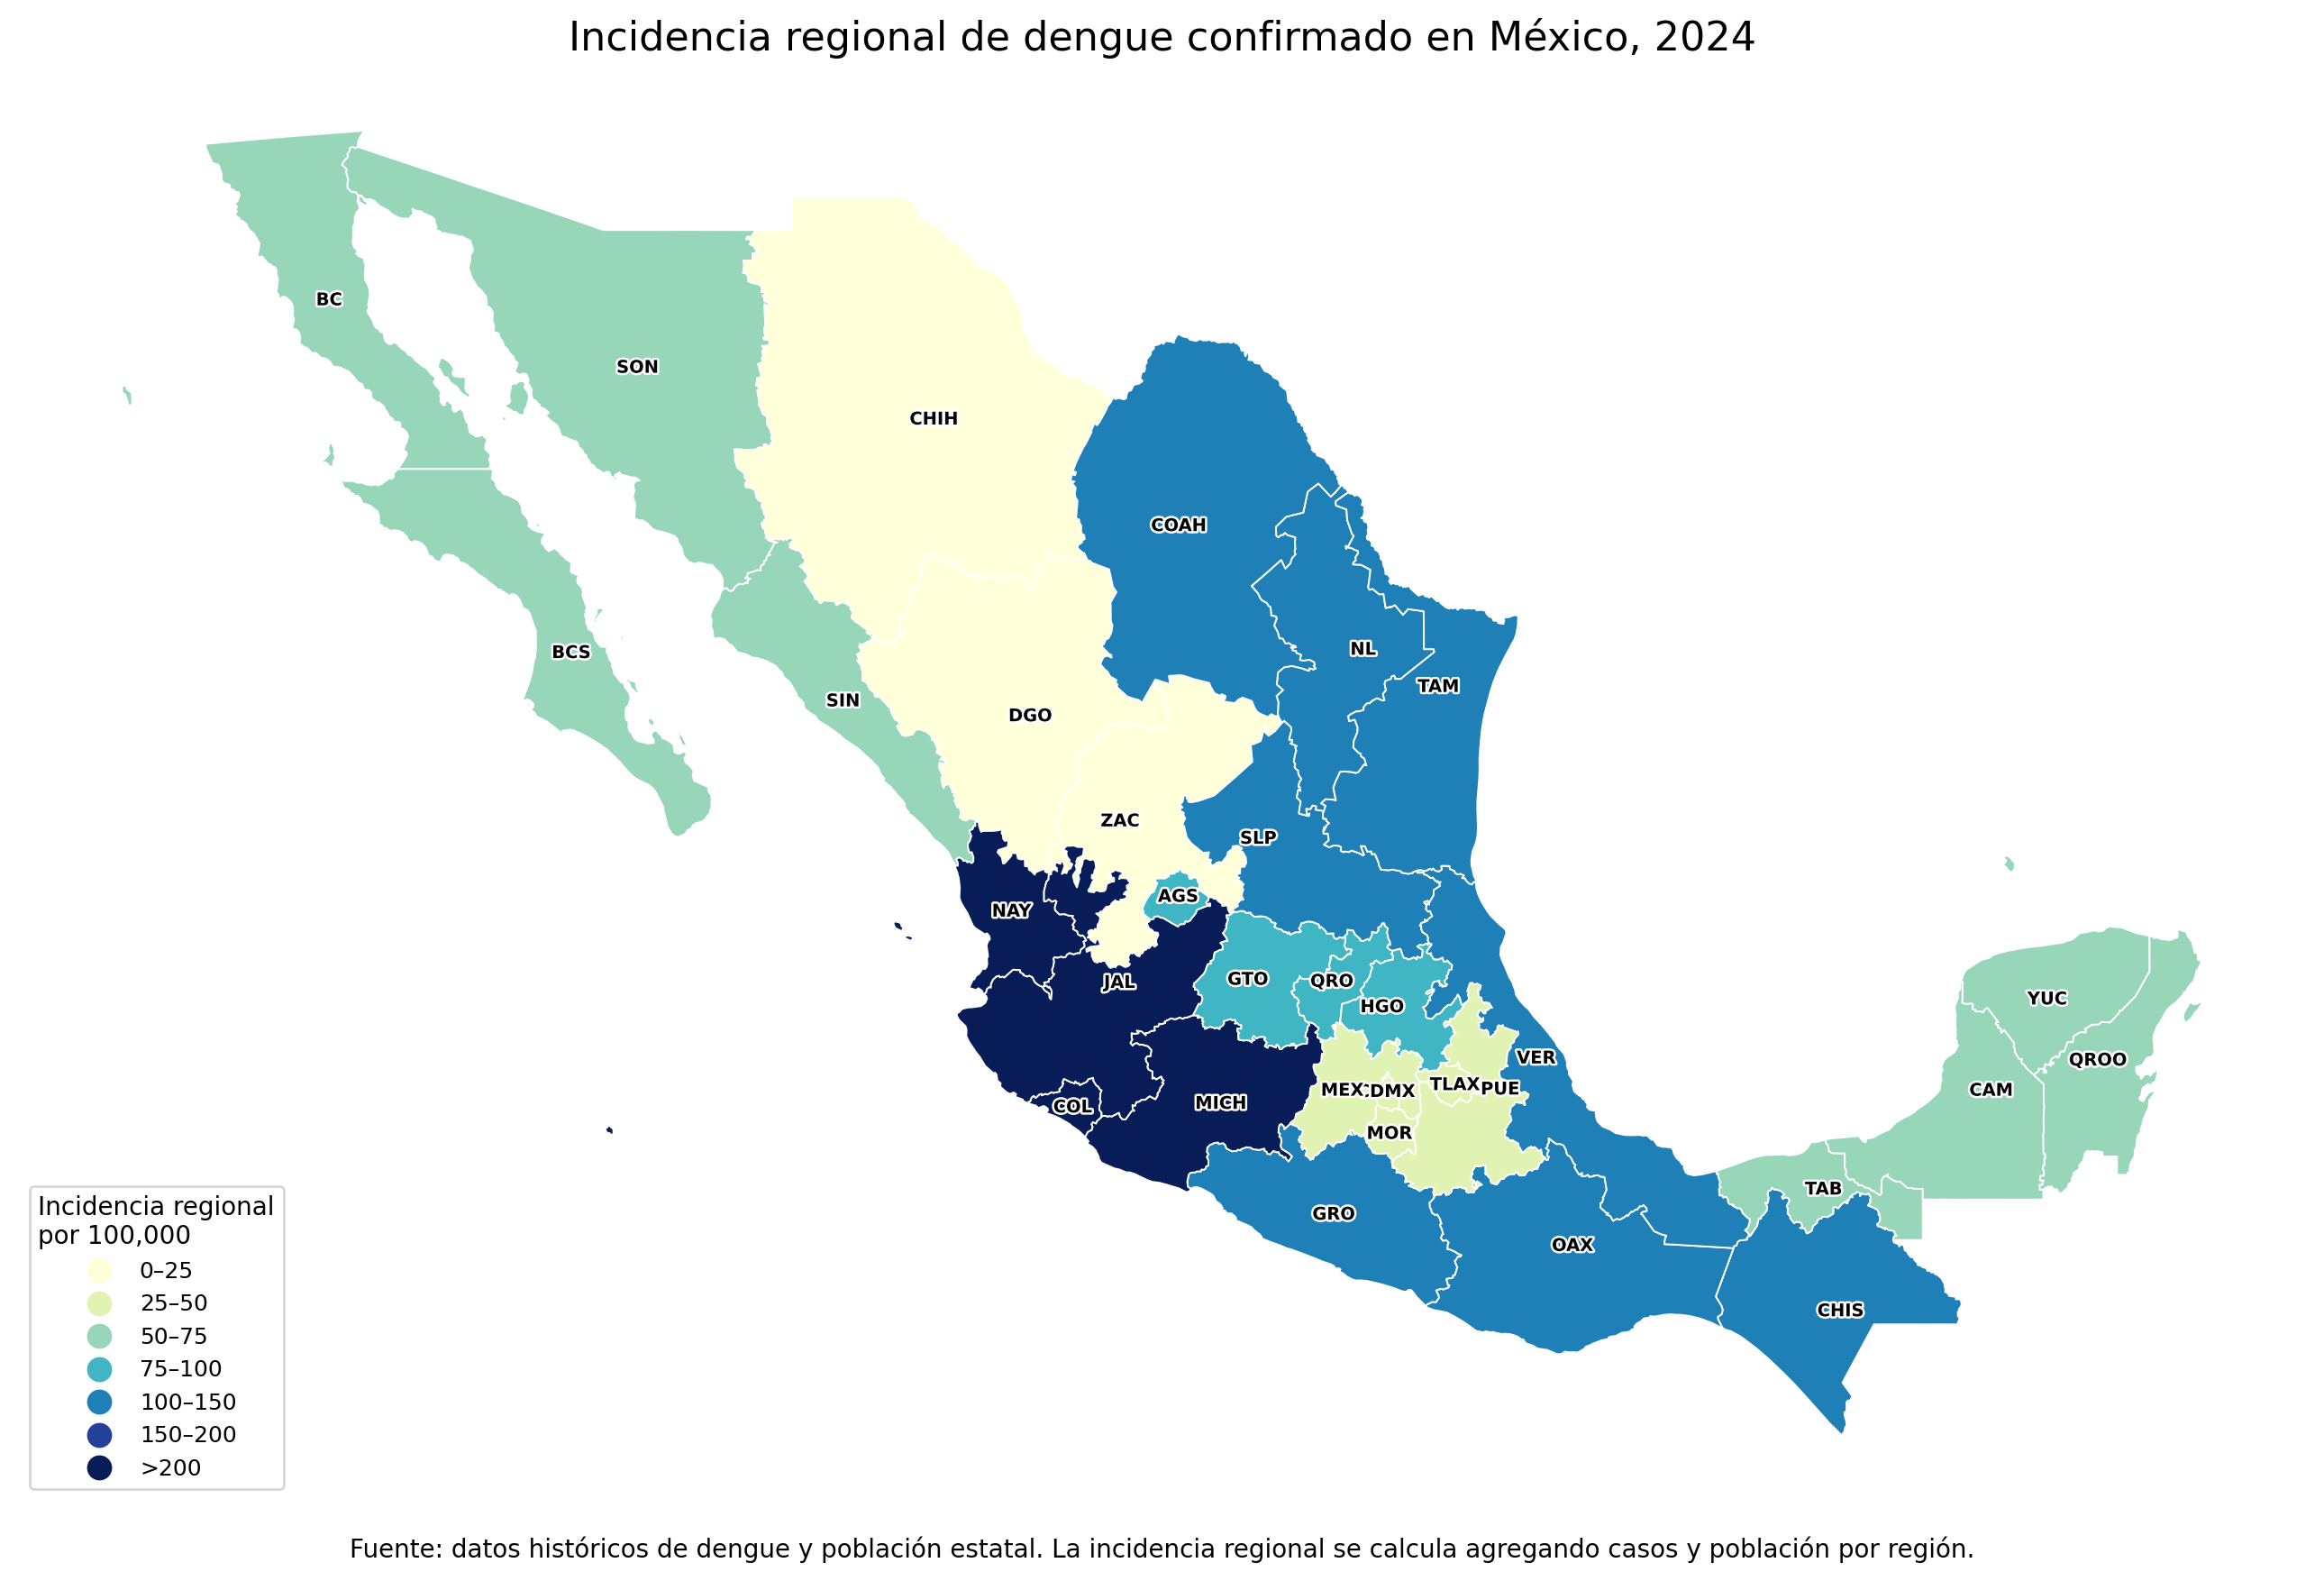

Figura guardada en: datos_dengue_historicos/figuras_mapas/fig_03_mapa_incidencia_regional_dengue_2024.png

Tablas guardadas en:
/Users/juanalbertomartinez/Desktop/Dengue/datos_dengue_historicos/tablas_mapas/tabla_03_incidencia_regional_2024.csv
/Users/juanalbertomartinez/Desktop/Dengue/datos_dengue_historicos/tablas_mapas/tabla_04_mapa_incidencia_regional_2024.csv


In [28]:
# ------------------------------------------------------------
# 5. Mapa
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 10), dpi=200)

gdf_region_2024.plot(
    column="CLASE_INCIDENCIA_REGIONAL",
    categorical=True,
    cmap="YlGnBu",
    linewidth=0.7,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "title": "Incidencia regional\npor 100,000",
        "loc": "lower left",
        "fontsize": 9,
        "title_fontsize": 10
    },
    ax=ax
)

# Etiquetas abreviadas de estados
for _, row in gdf_region_2024.iterrows():
    x, y = row["label_pt"].x, row["label_pt"].y
    ax.text(
        x,
        y,
        row["ABREV"],
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
        color="black",
        path_effects=[
            patheffects.withStroke(linewidth=1.8, foreground="white")
        ]
    )

ax.set_title(
    "Incidencia regional de dengue confirmado en México, 2024",
    fontsize=16
)

ax.text(
    0.5,
    -0.04,
    "Fuente: datos históricos de dengue y población estatal. "
    "La incidencia regional se calcula agregando casos y población por región.",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.axis("off")

plt.tight_layout()

fig_path = FIG_DIR / "fig_03_mapa_incidencia_regional_dengue_2024.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {fig_path}")

# ------------------------------------------------------------
# 6. Guardar tablas
# ------------------------------------------------------------

incidencia_region_2024.to_csv(
    TABLE_DIR / "tabla_03_incidencia_regional_2024.csv",
    index=False,
    encoding="utf-8"
)

gdf_region_2024.drop(
    columns=["geometry", "label_pt"],
    errors="ignore"
).to_csv(
    TABLE_DIR / "tabla_04_mapa_incidencia_regional_2024.csv",
    index=False,
    encoding="utf-8"
)

print("\nTablas guardadas en:")
print((TABLE_DIR / "tabla_03_incidencia_regional_2024.csv").resolve())
print((TABLE_DIR / "tabla_04_mapa_incidencia_regional_2024.csv").resolve())

Región 4: Colima, Jalisco, Michoacán, Nayarit → 235.0 por 100,000
Región 3: Coahuila, Nuevo León, San Luis Potosí, Tamaulipas → 131.9
Región 5: Chiapas, Guerrero, Oaxaca, Veracruz → 103.5
Región 8: Aguascalientes, Guanajuato, Hidalgo, Querétaro → 85.5

In [33]:
# ============================================================
# Celda 6. Mapa de incidencia media estatal, 2020-2025
# ============================================================

# ------------------------------------------------------------
# 1. Calcular incidencia media estatal 2020-2025
# ------------------------------------------------------------

incidencia_media_2020_2025 = (
    incidencia_estado_anio
    .query("ANIO <= 2025")
    .groupby("ESTADO", as_index=False)
    .agg(
        INCIDENCIA_MEDIA_100K=("INCIDENCIA_100K", "mean"),
        INCIDENCIA_MAXIMA_100K=("INCIDENCIA_100K", "max"),
        CASOS_CONFIRMADOS=("CASOS_CONFIRMADOS", "sum"),
        POBLACION_MEDIA=("POBLACION", "mean")
    )
)

incidencia_media_2020_2025 = incidencia_media_2020_2025.sort_values(
    "INCIDENCIA_MEDIA_100K",
    ascending=False
)

print("Top 10 estados por incidencia media anual, 2020-2025:")
display(
    incidencia_media_2020_2025
    .head(10)
    .round({
        "INCIDENCIA_MEDIA_100K": 1,
        "INCIDENCIA_MAXIMA_100K": 1,
        "POBLACION_MEDIA": 0
    })
)

# ------------------------------------------------------------
# 2. Unir al GeoDataFrame
# ------------------------------------------------------------

gdf_media_2020_2025 = gdf.merge(
    incidencia_media_2020_2025,
    on="ESTADO",
    how="left"
)

gdf_media_2020_2025["ABREV"] = gdf_media_2020_2025["ESTADO"].map(abreviaturas)
gdf_media_2020_2025["label_pt"] = gdf_media_2020_2025.geometry.representative_point()

print("\nValores faltantes después del cruce:")
print(
    gdf_media_2020_2025[
        ["ESTADO", "INCIDENCIA_MEDIA_100K", "INCIDENCIA_MAXIMA_100K"]
    ].isna().sum()
)

# ------------------------------------------------------------
# 3. Clases de incidencia media
# ------------------------------------------------------------

bins = [0, 5, 15, 30, 50, 75, 100, 150]
labels = ["0–5", "5–15", "15–30", "30–50", "50–75", "75–100", ">100"]

gdf_media_2020_2025["CLASE_INCIDENCIA_MEDIA"] = pd.cut(
    gdf_media_2020_2025["INCIDENCIA_MEDIA_100K"],
    bins=bins,
    labels=labels,
    include_lowest=True
)



Top 10 estados por incidencia media anual, 2020-2025:


,ESTADO,INCIDENCIA_MEDIA_100K,INCIDENCIA_MAXIMA_100K,CASOS_CONFIRMADOS,POBLACION_MEDIA
7,COLIMA,139.4,661.5,6358,755430.0
16,MORELOS,101.8,310.3,12424,2026492.0
17,NAYARIT,91.1,419.3,7119,1287344.0
30,YUCATAN,78.2,423.5,11504,2437261.0
2,BAJA CALIFORNIA SUR,76.9,289.9,4078,859004.0
11,GUERRERO,57.4,182.7,12422,3602770.0
22,QUINTANA ROO,57.3,245.9,6944,1999082.0
26,TABASCO,56.4,144.5,8314,2452209.0
13,JALISCO,55.7,231.5,29304,8698141.0
29,VERACRUZ,51.3,126.4,25045,8138215.0



Valores faltantes después del cruce:
ESTADO                    0
INCIDENCIA_MEDIA_100K     0
INCIDENCIA_MAXIMA_100K    0
dtype: int64


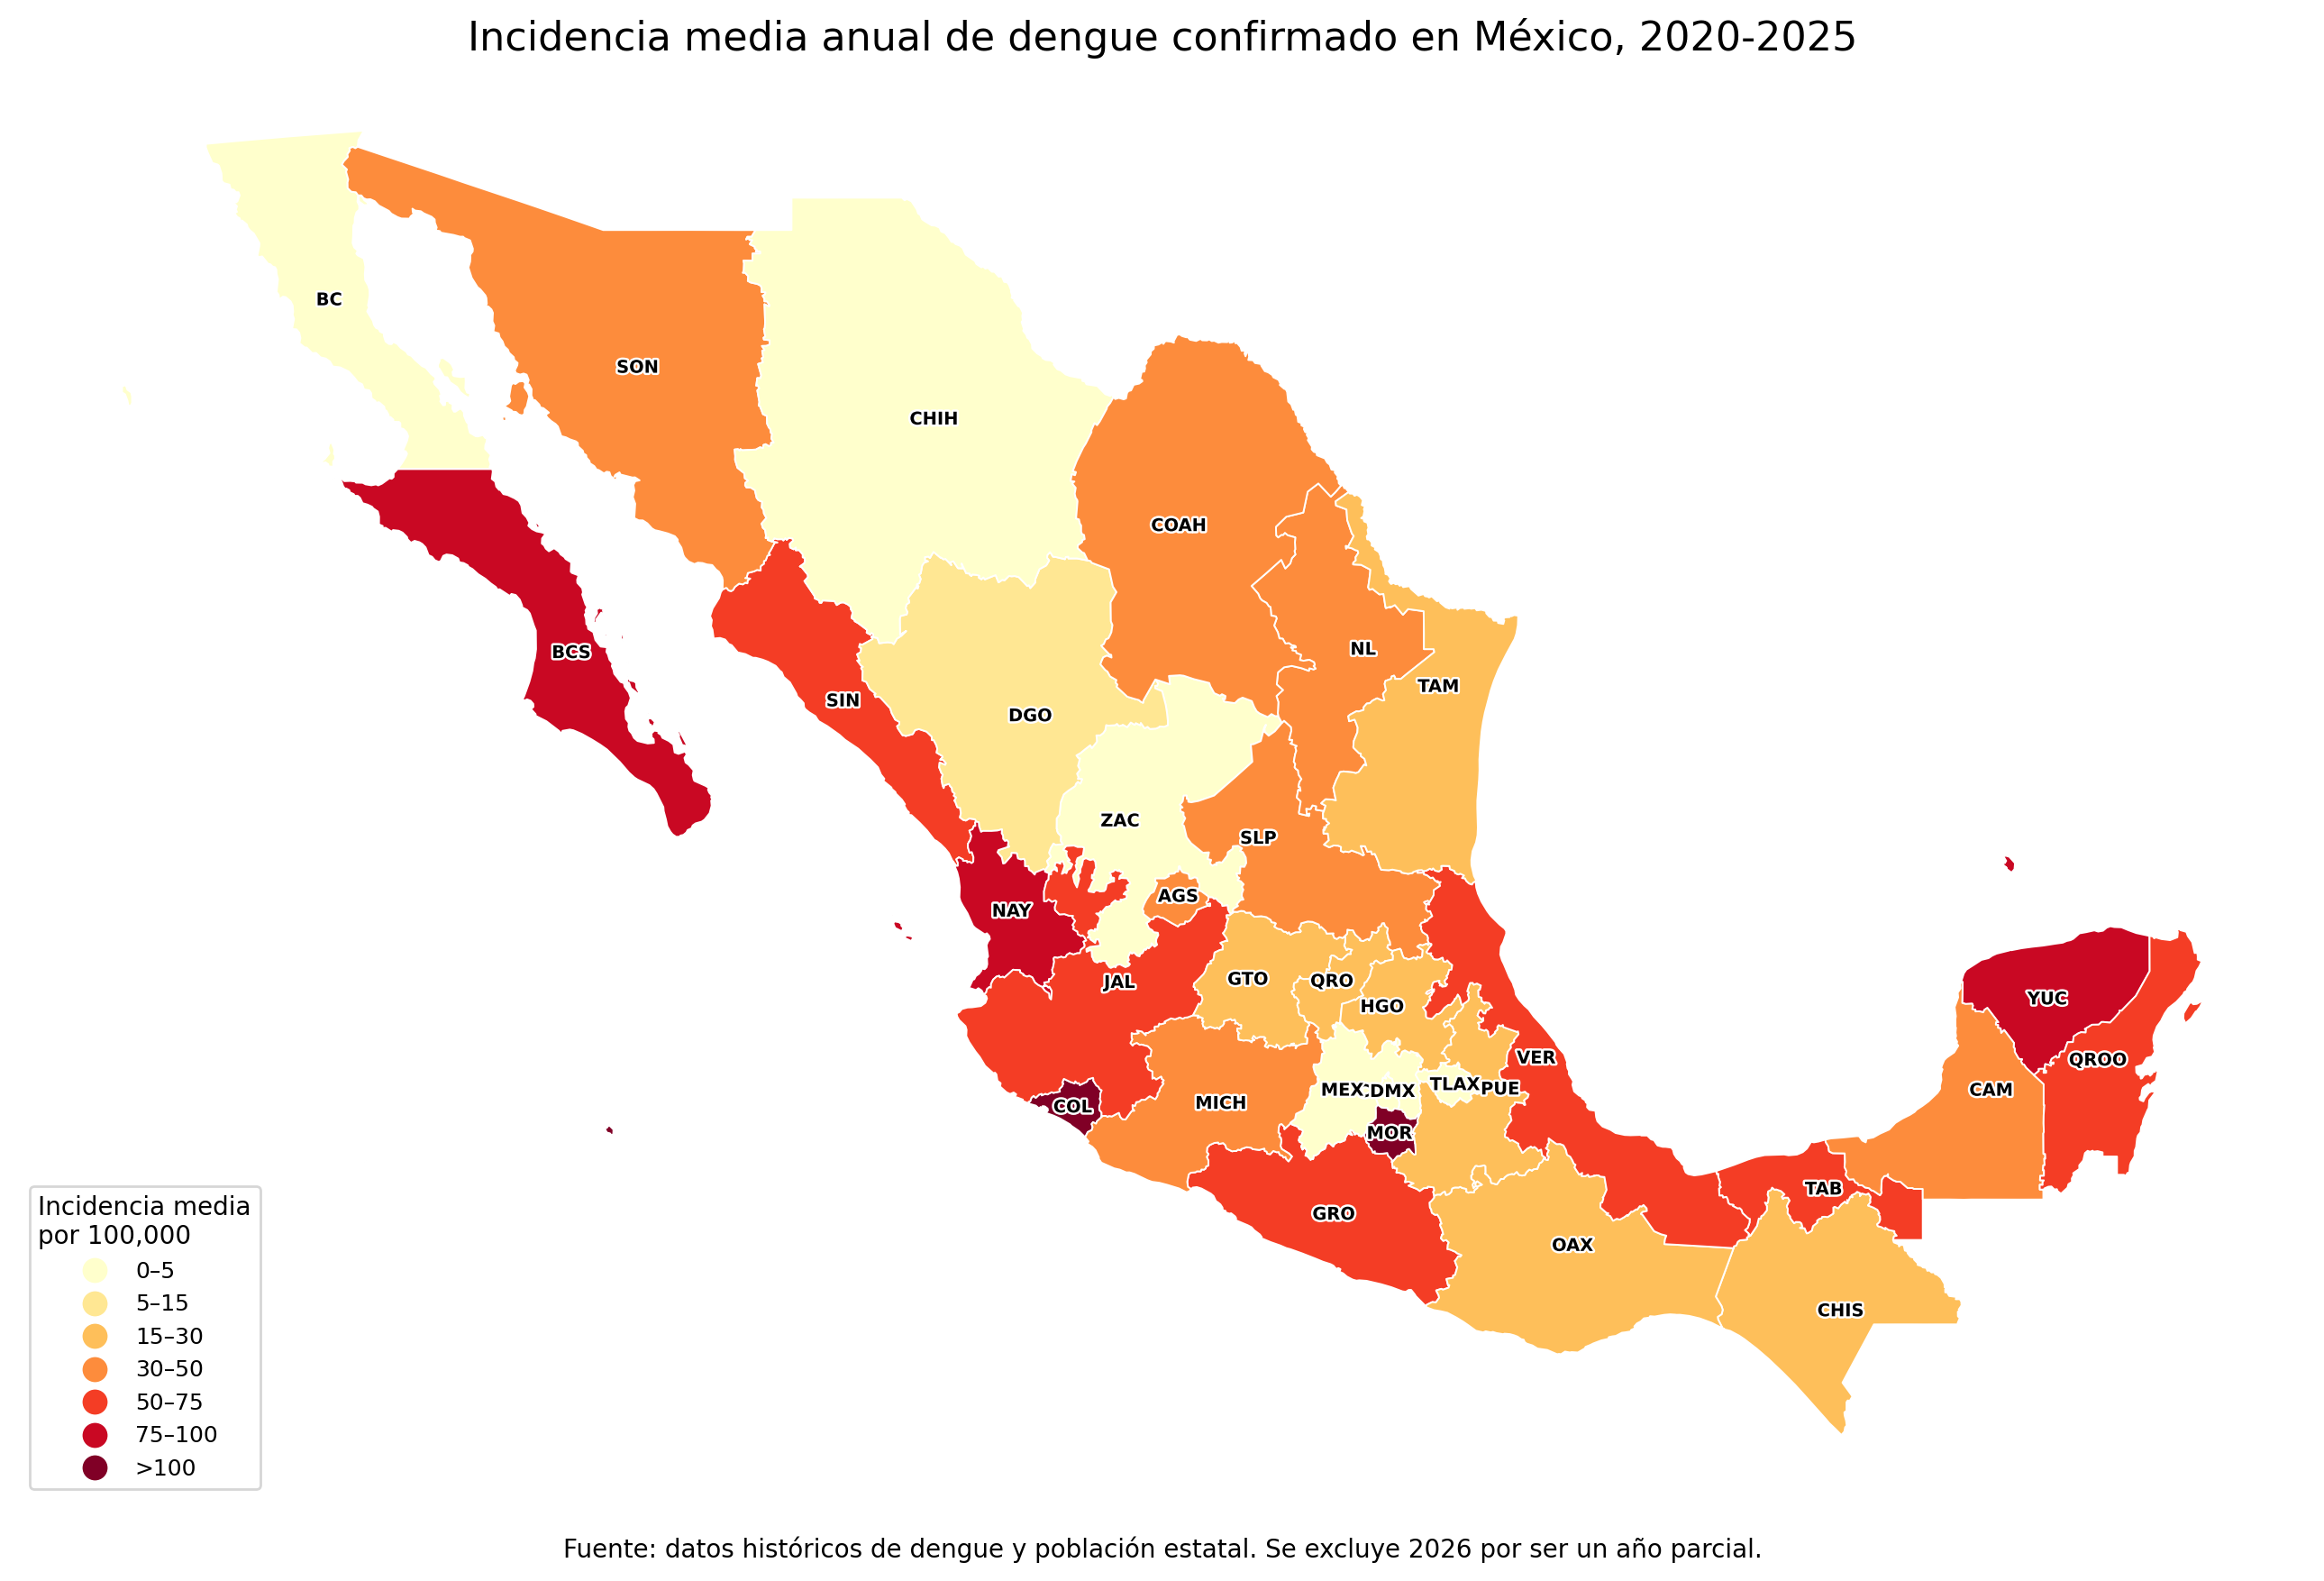

Figura guardada en: datos_dengue_historicos/figuras_mapas/fig_04_mapa_incidencia_media_estatal_dengue_2020_2025.png


In [34]:
# ------------------------------------------------------------
# 4. Mapa
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 10), dpi=200)

gdf_media_2020_2025.plot(
    column="CLASE_INCIDENCIA_MEDIA",
    categorical=True,
    cmap="YlOrRd",
    linewidth=0.7,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "title": "Incidencia media\npor 100,000",
        "loc": "lower left",
        "fontsize": 9,
        "title_fontsize": 10
    },
    ax=ax
)

for _, row in gdf_media_2020_2025.iterrows():
    x, y = row["label_pt"].x, row["label_pt"].y
    ax.text(
        x,
        y,
        row["ABREV"],
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
        color="black",
        path_effects=[
            patheffects.withStroke(linewidth=1.8, foreground="white")
        ]
    )

ax.set_title(
    "Incidencia media anual de dengue confirmado en México, 2020-2025",
    fontsize=16
)

ax.text(
    0.5,
    -0.04,
    "Fuente: datos históricos de dengue y población estatal. "
    "Se excluye 2026 por ser un año parcial.",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.axis("off")

plt.tight_layout()

fig_path = FIG_DIR / "fig_04_mapa_incidencia_media_estatal_dengue_2020_2025.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {fig_path}")

# ------------------------------------------------------------
# 5. Guardar tabla


gdf_media_2020_2025.drop(
    columns=["geometry", "label_pt"],
    errors="ignore"
).to_csv(
    TABLE_DIR / "tabla_05_mapa_incidencia_media_estatal_2020_2025.csv",
    index=False,
    encoding="utf-8"
)

Se observa que la incidencia media alta se concentra principalmente en: Colima, Morelos, Nayarit, Yucatán, Baja California Sur,
Guerrero, Quintana Roo, Tabasco, Jalisco y Veracruz.

In [37]:
# ============================================================
# Celda 7. Mapa de incidencia máxima estatal anual, 2020-2025
# ============================================================

# ------------------------------------------------------------
# 1. Identificar incidencia máxima y año pico por estado
# ------------------------------------------------------------

incidencia_2020_2025 = incidencia_estado_anio.query("ANIO <= 2025").copy()

idx_max = (
    incidencia_2020_2025
    .groupby("ESTADO")["INCIDENCIA_100K"]
    .idxmax()
)

incidencia_maxima_2020_2025 = (
    incidencia_2020_2025
    .loc[idx_max]
    .copy()
    .rename(columns={
        "ANIO": "ANIO_MAXIMO",
        "CASOS_CONFIRMADOS": "CASOS_ANIO_MAXIMO",
        "INCIDENCIA_100K": "INCIDENCIA_MAXIMA_100K"
    })
)

incidencia_maxima_2020_2025 = incidencia_maxima_2020_2025[
    [
        "ESTADO",
        "ANIO_MAXIMO",
        "CASOS_ANIO_MAXIMO",
        "POBLACION",
        "INCIDENCIA_MAXIMA_100K"
    ]
].sort_values("INCIDENCIA_MAXIMA_100K", ascending=False)

print("Top 15 estados por incidencia máxima anual, 2020-2025:")
print(
    incidencia_maxima_2020_2025
    .head(15)
    .round({"INCIDENCIA_MAXIMA_100K": 1})
)

# ------------------------------------------------------------
# 2. Unir al GeoDataFrame
# ------------------------------------------------------------

gdf_maxima_2020_2025 = gdf.merge(
    incidencia_maxima_2020_2025,
    on="ESTADO",
    how="left"
)

gdf_maxima_2020_2025["ABREV"] = gdf_maxima_2020_2025["ESTADO"].map(abreviaturas)
gdf_maxima_2020_2025["label_pt"] = gdf_maxima_2020_2025.geometry.representative_point()

print("\nValores faltantes después del cruce:")
print(
    gdf_maxima_2020_2025[
        ["ESTADO", "ANIO_MAXIMO", "INCIDENCIA_MAXIMA_100K"]
    ].isna().sum()
)

# ------------------------------------------------------------
# 3. Clases de incidencia máxima
# ------------------------------------------------------------

bins = [0, 10, 25, 50, 100, 200, 400, 700]
labels = ["0–10", "10–25", "25–50", "50–100", "100–200", "200–400", ">400"]

gdf_maxima_2020_2025["CLASE_INCIDENCIA_MAXIMA"] = pd.cut(
    gdf_maxima_2020_2025["INCIDENCIA_MAXIMA_100K"],
    bins=bins,
    labels=labels,
    include_lowest=True
)



Top 15 estados por incidencia máxima anual, 2020-2025:
                  ESTADO  ANIO_MAXIMO  CASOS_ANIO_MAXIMO  POBLACION  \
135               COLIMA         2024               5043     762387   
126              YUCATAN         2023              10385    2452378   
145              NAYARIT         2024               5490    1309432   
144              MORELOS         2024               6343    2043884   
130  BAJA CALIFORNIA SUR         2024               2569     886050   
118         QUINTANA ROO         2023               4967    2019606   
141              JALISCO         2024              20419    8820915   
128       AGUASCALIENTES         2024               3205    1530185   
99              CAMPECHE         2023               1906     950291   
139             GUERRERO         2024               6589    3606733   
146           NUEVO LEON         2024              10544    6308199   
134             COAHUILA         2024               5584    3358991   
152              SINAL

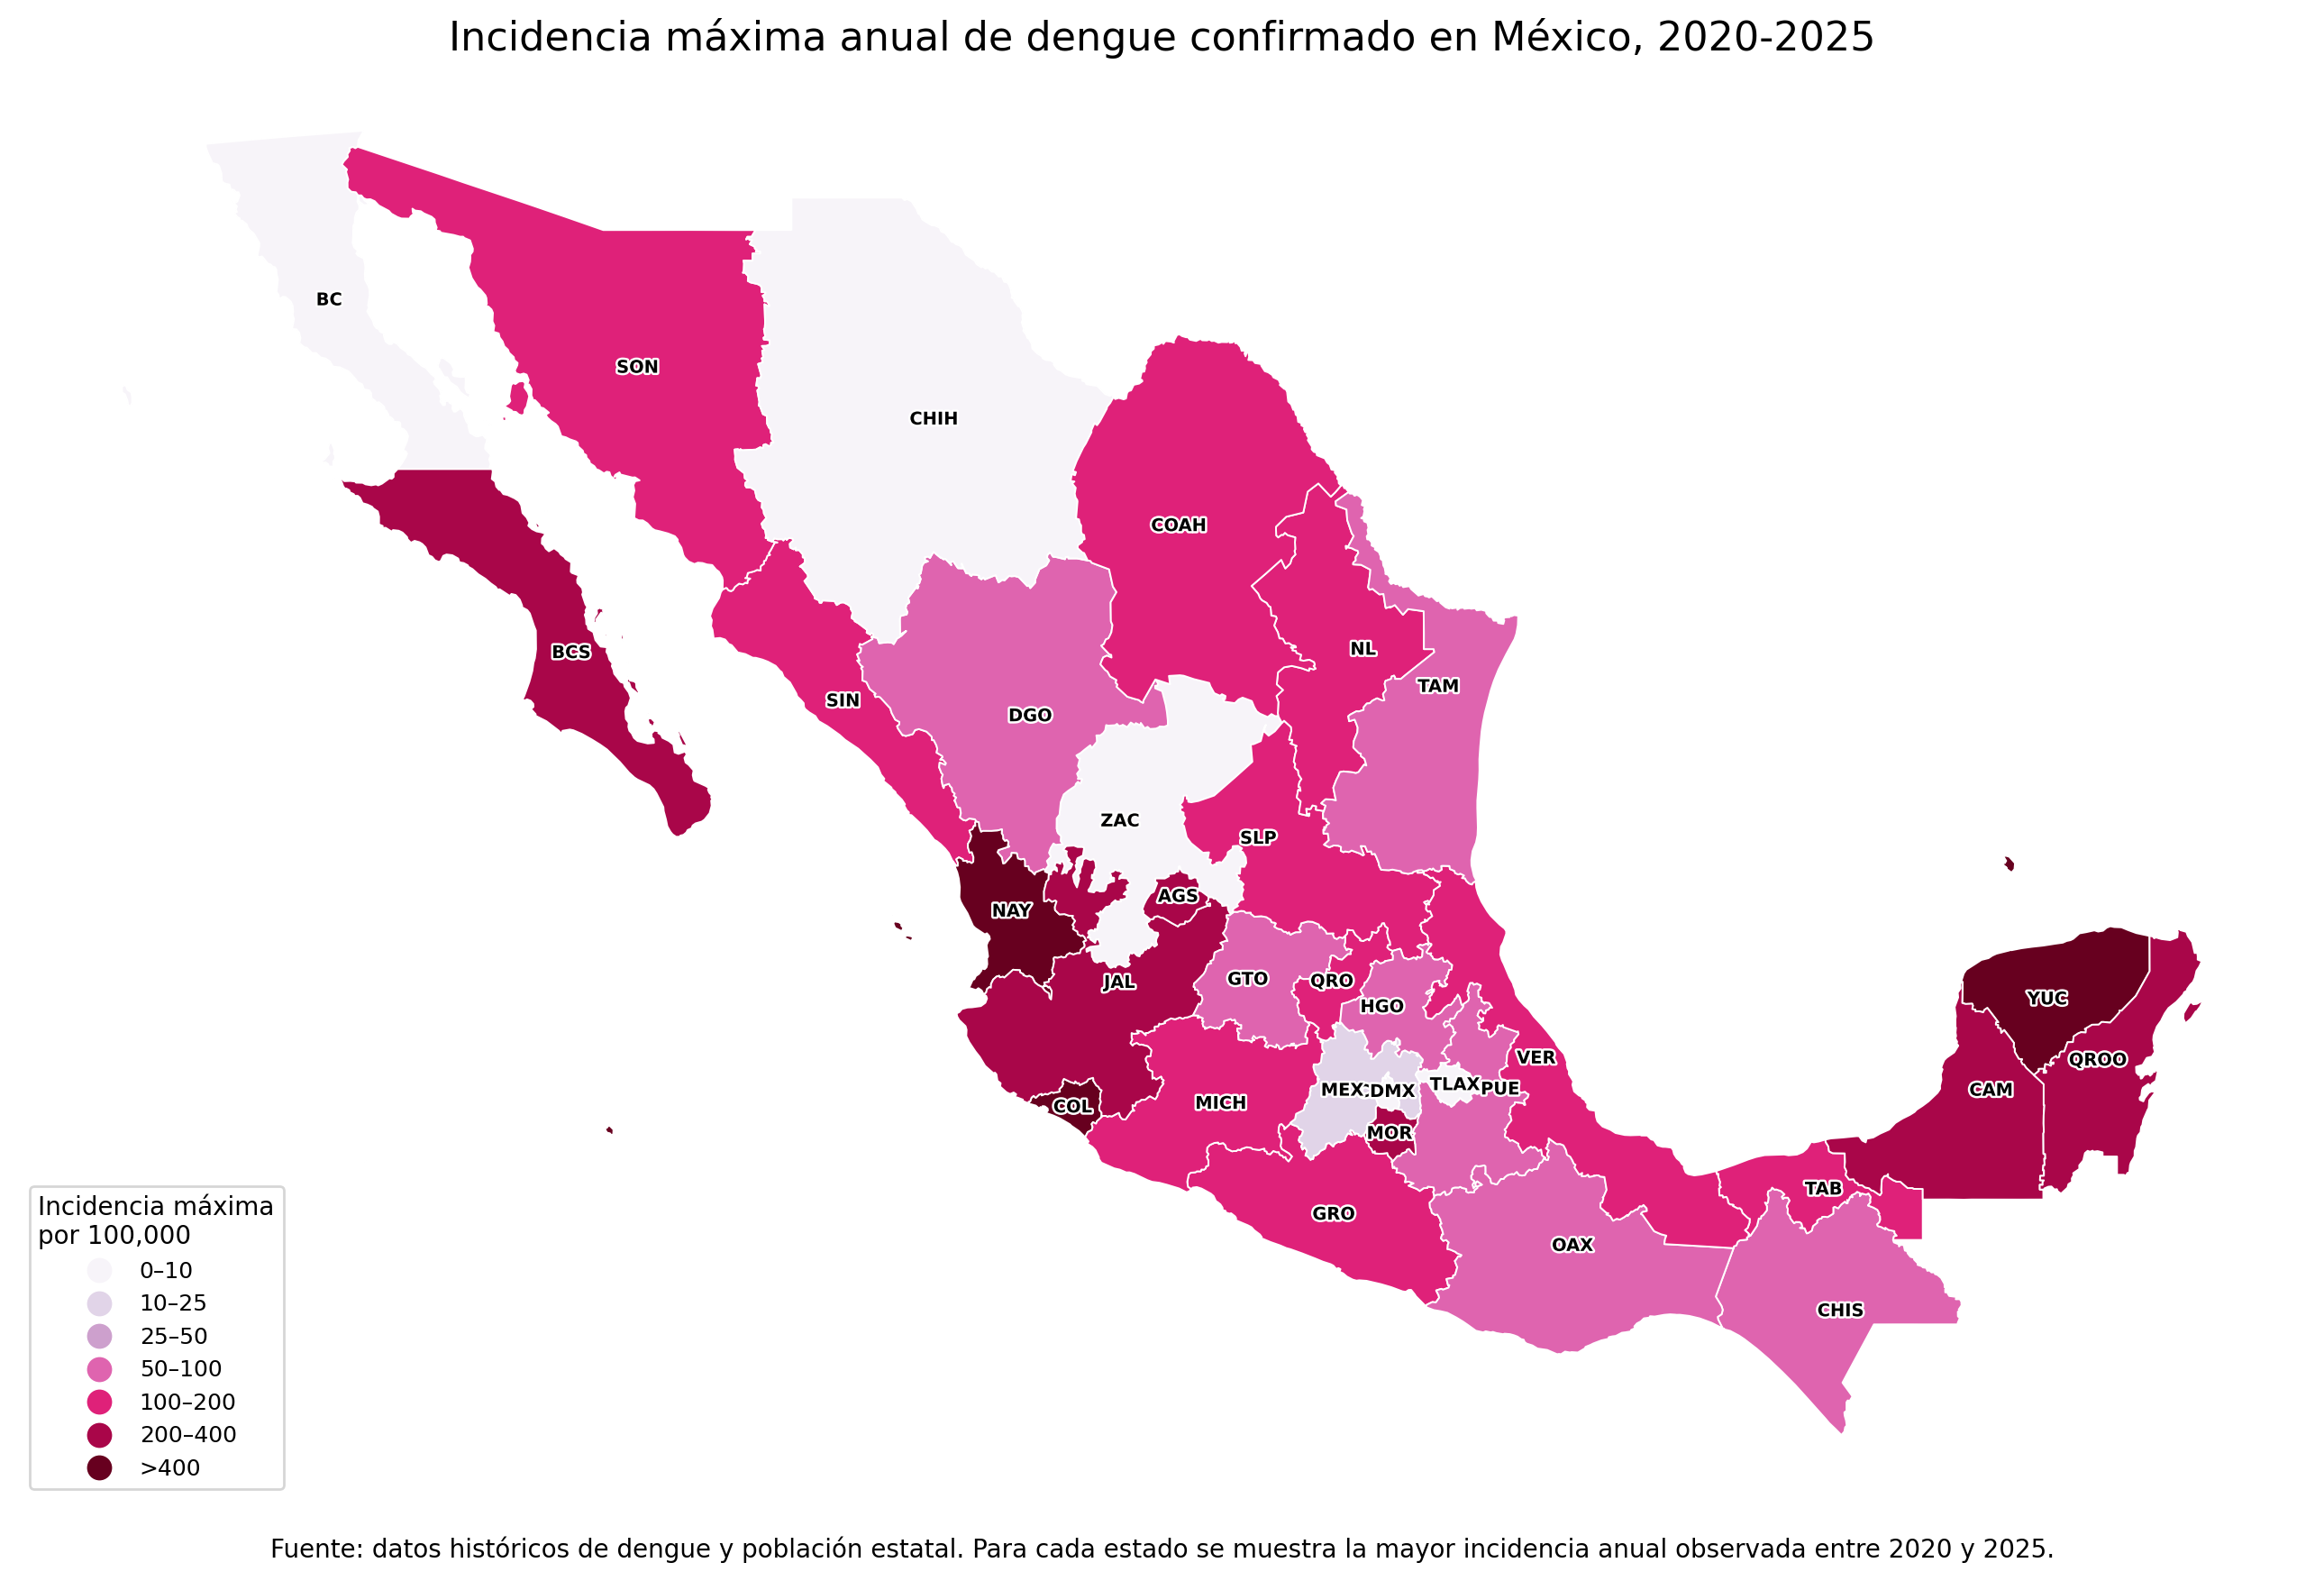

In [38]:
# ------------------------------------------------------------
# 4. Mapa
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 10), dpi=200)

gdf_maxima_2020_2025.plot(
    column="CLASE_INCIDENCIA_MAXIMA",
    categorical=True,
    cmap="PuRd",
    linewidth=0.7,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "title": "Incidencia máxima\npor 100,000",
        "loc": "lower left",
        "fontsize": 9,
        "title_fontsize": 10
    },
    ax=ax
)

for _, row in gdf_maxima_2020_2025.iterrows():
    x, y = row["label_pt"].x, row["label_pt"].y
    ax.text(
        x,
        y,
        row["ABREV"],
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
        color="black",
        path_effects=[
            patheffects.withStroke(linewidth=1.8, foreground="white")
        ]
    )

ax.set_title(
    "Incidencia máxima anual de dengue confirmado en México, 2020-2025",
    fontsize=16
)

ax.text(
    0.5,
    -0.04,
    "Fuente: datos históricos de dengue y población estatal. "
    "Para cada estado se muestra la mayor incidencia anual observada entre 2020 y 2025.",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.axis("off")

plt.tight_layout()

fig_path = FIG_DIR / "fig_05_mapa_incidencia_maxima_estatal_dengue_2020_2025.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()


# ------------------------------------------------------------
# 5. Guardar tabla
# ------------------------------------------------------------

gdf_maxima_2020_2025.drop(
    columns=["geometry", "label_pt"],
    errors="ignore"
).to_csv(
    TABLE_DIR / "tabla_06_mapa_incidencia_maxima_estatal_2020_2025.csv",
    index=False,
    encoding="utf-8"
)



Incidencia media 2020–2025:
resume carga promedio.

Incidencia máxima 2020–2025:
resume el peor año observado para cada estado.


Aquí se ve que varios máximos corresponden a 2024, pero algunos estados tuvieron su máximo en otros años, por ejemplo:

Yucatán, Quintana Roo y Campeche: máximo en 2023.
Sonora: máximo en 2025.

In [39]:
# ============================================================
# Celda 8. Mapa del año de máxima incidencia estatal, 2020-2025
# ============================================================

# ------------------------------------------------------------
# 1. Usamos la tabla ya construida:
# incidencia_maxima_2020_2025
# ------------------------------------------------------------

print("Año de máxima incidencia anual por estado:")
print(
    incidencia_maxima_2020_2025
    .sort_values(["ANIO_MAXIMO", "ESTADO"])
    .round({"INCIDENCIA_MAXIMA_100K": 1})
)

conteo_anio_maximo = (
    incidencia_maxima_2020_2025
    .groupby("ANIO_MAXIMO")
    .size()
    .reset_index(name="NUM_ESTADOS")
    .sort_values("ANIO_MAXIMO")
)

print("\nNúmero de estados según año de máxima incidencia:")
print(conteo_anio_maximo)

# ------------------------------------------------------------
# 2. Unir al GeoDataFrame
# ------------------------------------------------------------

gdf_anio_maximo = gdf.merge(
    incidencia_maxima_2020_2025,
    on="ESTADO",
    how="left"
)

gdf_anio_maximo["ABREV"] = gdf_anio_maximo["ESTADO"].map(abreviaturas)
gdf_anio_maximo["label_pt"] = gdf_anio_maximo.geometry.representative_point()

gdf_anio_maximo["ANIO_MAXIMO"] = gdf_anio_maximo["ANIO_MAXIMO"].astype(str)



Año de máxima incidencia anual por estado:
                  ESTADO  ANIO_MAXIMO  CASOS_ANIO_MAXIMO  POBLACION  \
99              CAMPECHE         2023               1906     950291   
118         QUINTANA ROO         2023               4967    2019606   
125             VERACRUZ         2023              10282    8131584   
126              YUCATAN         2023              10385    2452378   
128       AGUASCALIENTES         2024               3205    1530185   
129      BAJA CALIFORNIA         2024                109    4071872   
130  BAJA CALIFORNIA SUR         2024               2569     886050   
132              CHIAPAS         2024               4477    6028154   
133            CHIHUAHUA         2024                281    3996504   
134             COAHUILA         2024               5584    3358991   
135               COLIMA         2024               5043     762387   
136     DISTRITO FEDERAL         2024                321    9204018   
137              DURANGO         2

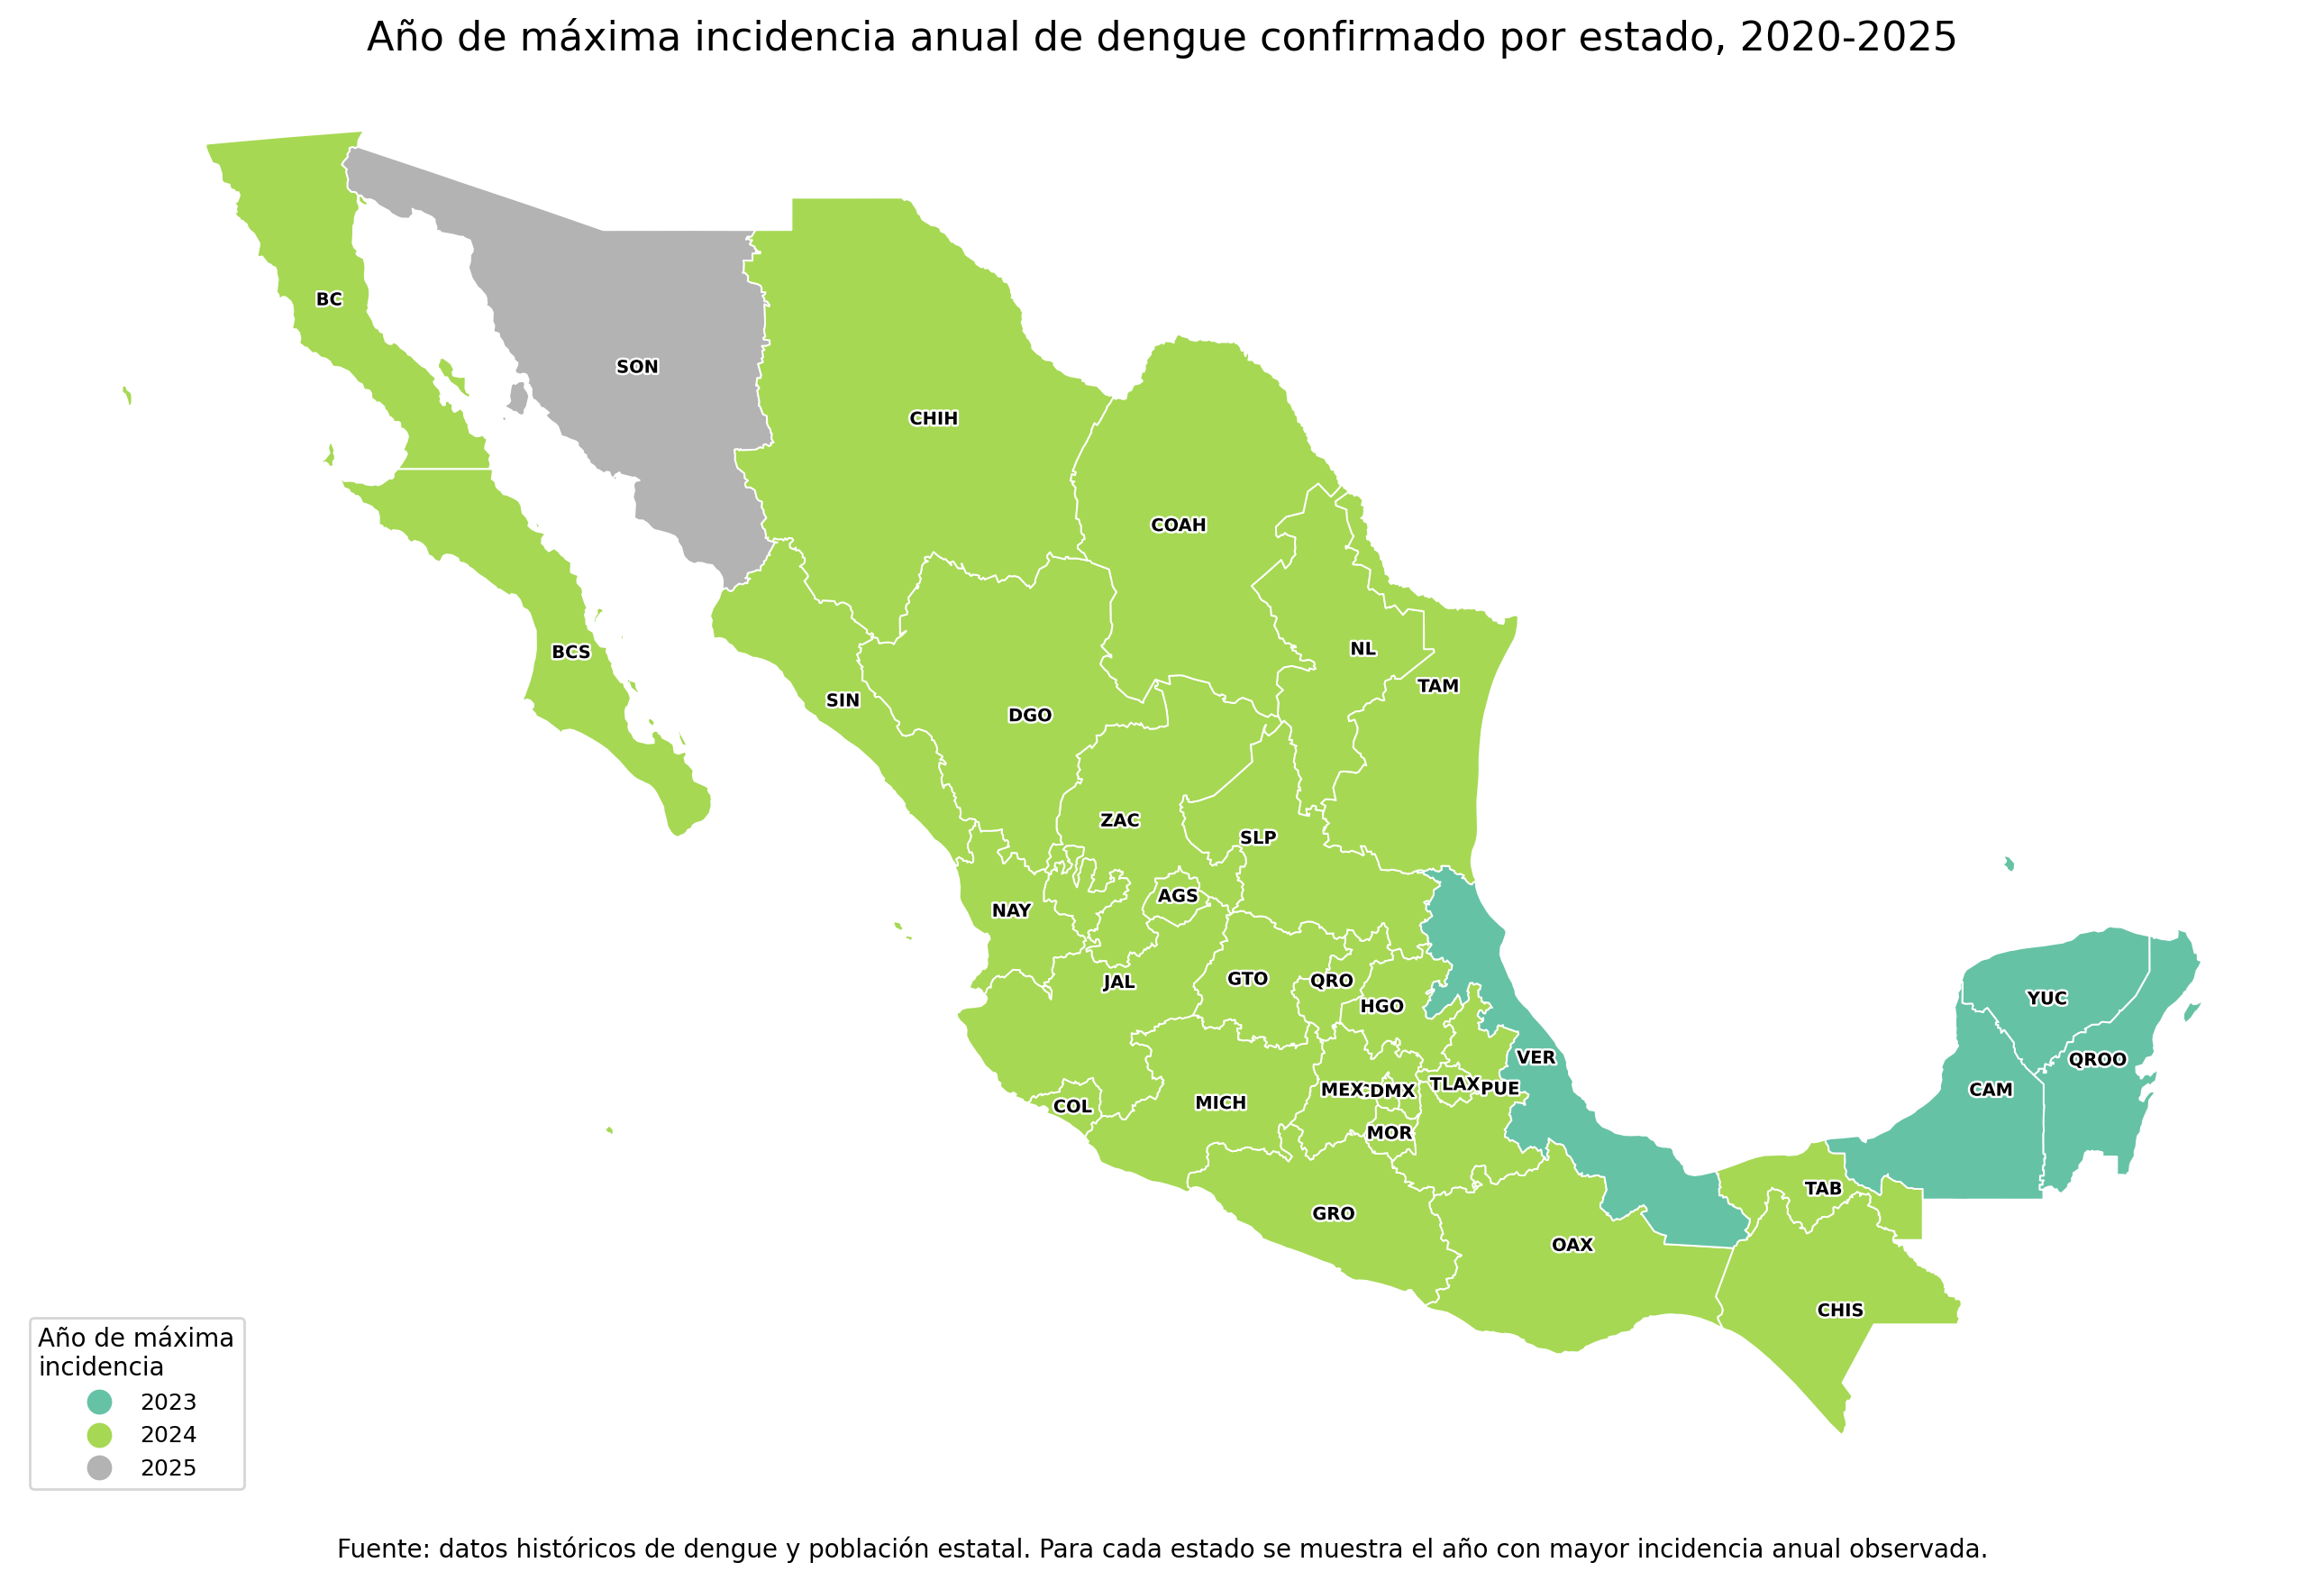

In [44]:
# ------------------------------------------------------------
# 3. Mapa
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 10), dpi=200)

gdf_anio_maximo.plot(
    column="ANIO_MAXIMO",
    categorical=True,
    cmap="Set2",
    linewidth=0.7,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "title": "Año de máxima\nincidencia",
        "loc": "lower left",
        "fontsize": 9,
        "title_fontsize": 10
    },
    ax=ax
)

for _, row in gdf_anio_maximo.iterrows():
    x, y = row["label_pt"].x, row["label_pt"].y
    ax.text(
        x,
        y,
        row["ABREV"],
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
        color="black",
        path_effects=[
            patheffects.withStroke(linewidth=1.8, foreground="white")
        ]
    )

ax.set_title(
    "Año de máxima incidencia anual de dengue confirmado por estado, 2020-2025",
    fontsize=16
)

ax.text(
    0.5,
    -0.04,
    "Fuente: datos históricos de dengue y población estatal. "
    "Para cada estado se muestra el año con mayor incidencia anual observada.",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.axis("off")

plt.tight_layout()

fig_path = FIG_DIR / "fig_06_mapa_anio_maxima_incidencia_estatal_dengue_2020_2025.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()



# ------------------------------------------------------------
# 4. Guardar tablas
# ------------------------------------------------------------

conteo_anio_maximo.to_csv(
    TABLE_DIR / "tabla_07_conteo_estados_anio_maxima_incidencia.csv",
    index=False,
    encoding="utf-8"
)

gdf_anio_maximo.drop(
    columns=["geometry", "label_pt"],
    errors="ignore"
).to_csv(
    TABLE_DIR / "tabla_08_mapa_anio_maxima_incidencia_estatal_2020_2025.csv",
    index=False,
    encoding="utf-8"
)



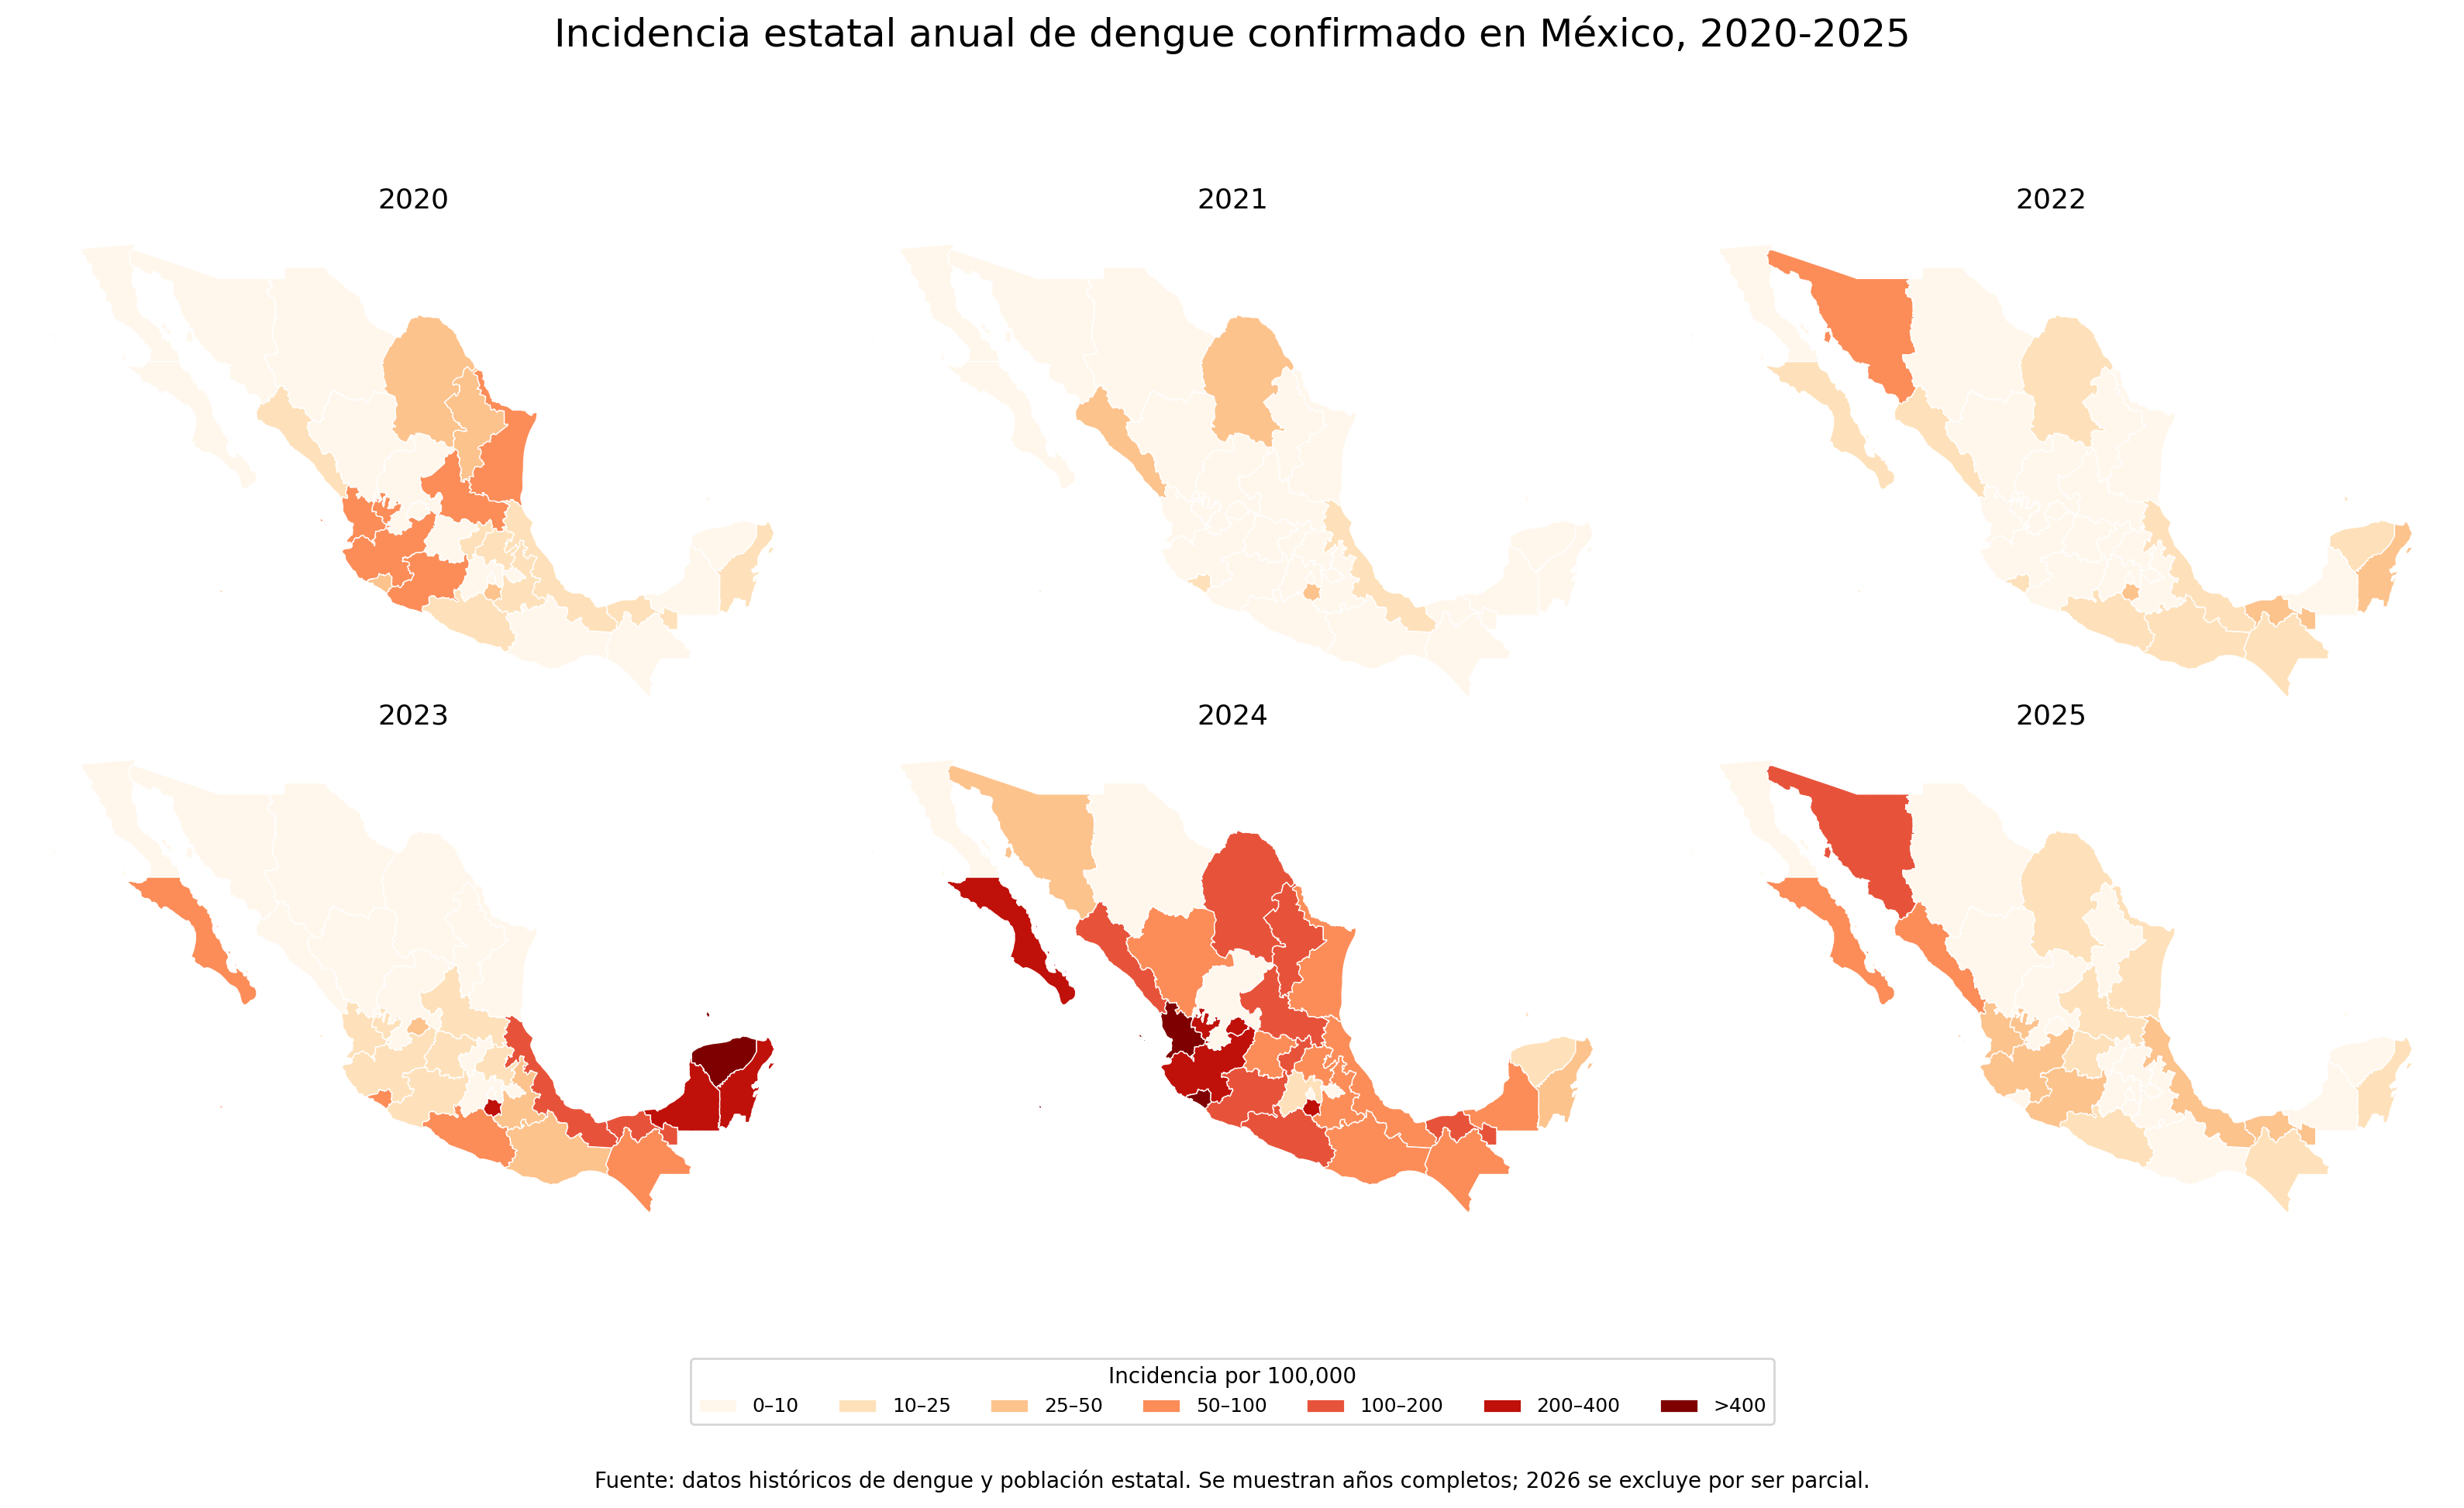

Figura guardada en: datos_dengue_historicos/figuras_mapas/fig_07_panel_mapas_incidencia_estatal_2020_2025.png


In [47]:
# ============================================================
# Celda 9. Panel de mapas de incidencia estatal anual, 2020-2025
# Versión corregida
# ============================================================

from matplotlib.patches import Patch
import matplotlib.colors as mcolors

# ------------------------------------------------------------
# 1. Preparar datos 2020-2025
# ------------------------------------------------------------

incidencia_panel = incidencia_estado_anio.query("ANIO <= 2025").copy()

gdf_panel = gdf.merge(
    incidencia_panel,
    on="ESTADO",
    how="left"
)

# Clases comunes para todos los años
bins = [0, 10, 25, 50, 100, 200, 400, 700]
labels = ["0–10", "10–25", "25–50", "50–100", "100–200", "200–400", ">400"]

gdf_panel["CLASE_INCIDENCIA"] = pd.cut(
    gdf_panel["INCIDENCIA_100K"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Paleta fija en formato hexadecimal
cmap = plt.get_cmap("OrRd", len(labels))

color_dict = {
    label: mcolors.to_hex(cmap(i))
    for i, label in enumerate(labels)
}

# ------------------------------------------------------------
# 2. Crear panel 2 x 3
# ------------------------------------------------------------

anios = [2020, 2021, 2022, 2023, 2024, 2025]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10),
    dpi=200
)

axes = axes.flatten()

for ax, anio in zip(axes, anios):
    
    gdf_anio = gdf_panel[gdf_panel["ANIO"] == anio].copy()
    
    # Convertir clase a texto y mapear a color hexadecimal
    gdf_anio["COLOR"] = (
        gdf_anio["CLASE_INCIDENCIA"]
        .astype(str)
        .map(color_dict)
        .fillna("#f0f0f0")
    )
    
    gdf_anio.plot(
        color=gdf_anio["COLOR"].tolist(),
        linewidth=0.5,
        edgecolor="white",
        ax=ax
    )
    
    ax.set_title(f"{anio}", fontsize=13)
    ax.axis("off")

# ------------------------------------------------------------
# 3. Leyenda común y ajustes finales
# ------------------------------------------------------------

legend_elements = [
    Patch(
        facecolor=color_dict[label],
        edgecolor="white",
        label=label
    )
    for label in labels
]

fig.legend(
    handles=legend_elements,
    title="Incidencia por 100,000",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.055),
    ncol=len(labels),
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

fig.suptitle(
    "Incidencia estatal anual de dengue confirmado en México, 2020-2025",
    fontsize=18,
    y=0.97
)

fig.text(
    0.5,
    0.02,
    "Fuente: datos históricos de dengue y población estatal. "
    "Se muestran años completos; 2026 se excluye por ser parcial.",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.12, 1, 0.94])

fig_path = FIG_DIR / "fig_07_panel_mapas_incidencia_estatal_2020_2025.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {fig_path}")

Casos confirmados por estado-año:


,ANIO,ESTADO,CASOS_CONFIRMADOS
0,2020,AGUASCALIENTES,4
1,2020,BAJA CALIFORNIA,5
2,2020,BAJA CALIFORNIA SUR,30
3,2020,CAMPECHE,40
4,2020,CHIAPAS,318



Totales nacionales por año:


,ANIO,CASOS_CONFIRMADOS
0,2020,24224
1,2021,6326
2,2022,12122
3,2023,53319
4,2024,123140
5,2025,21732


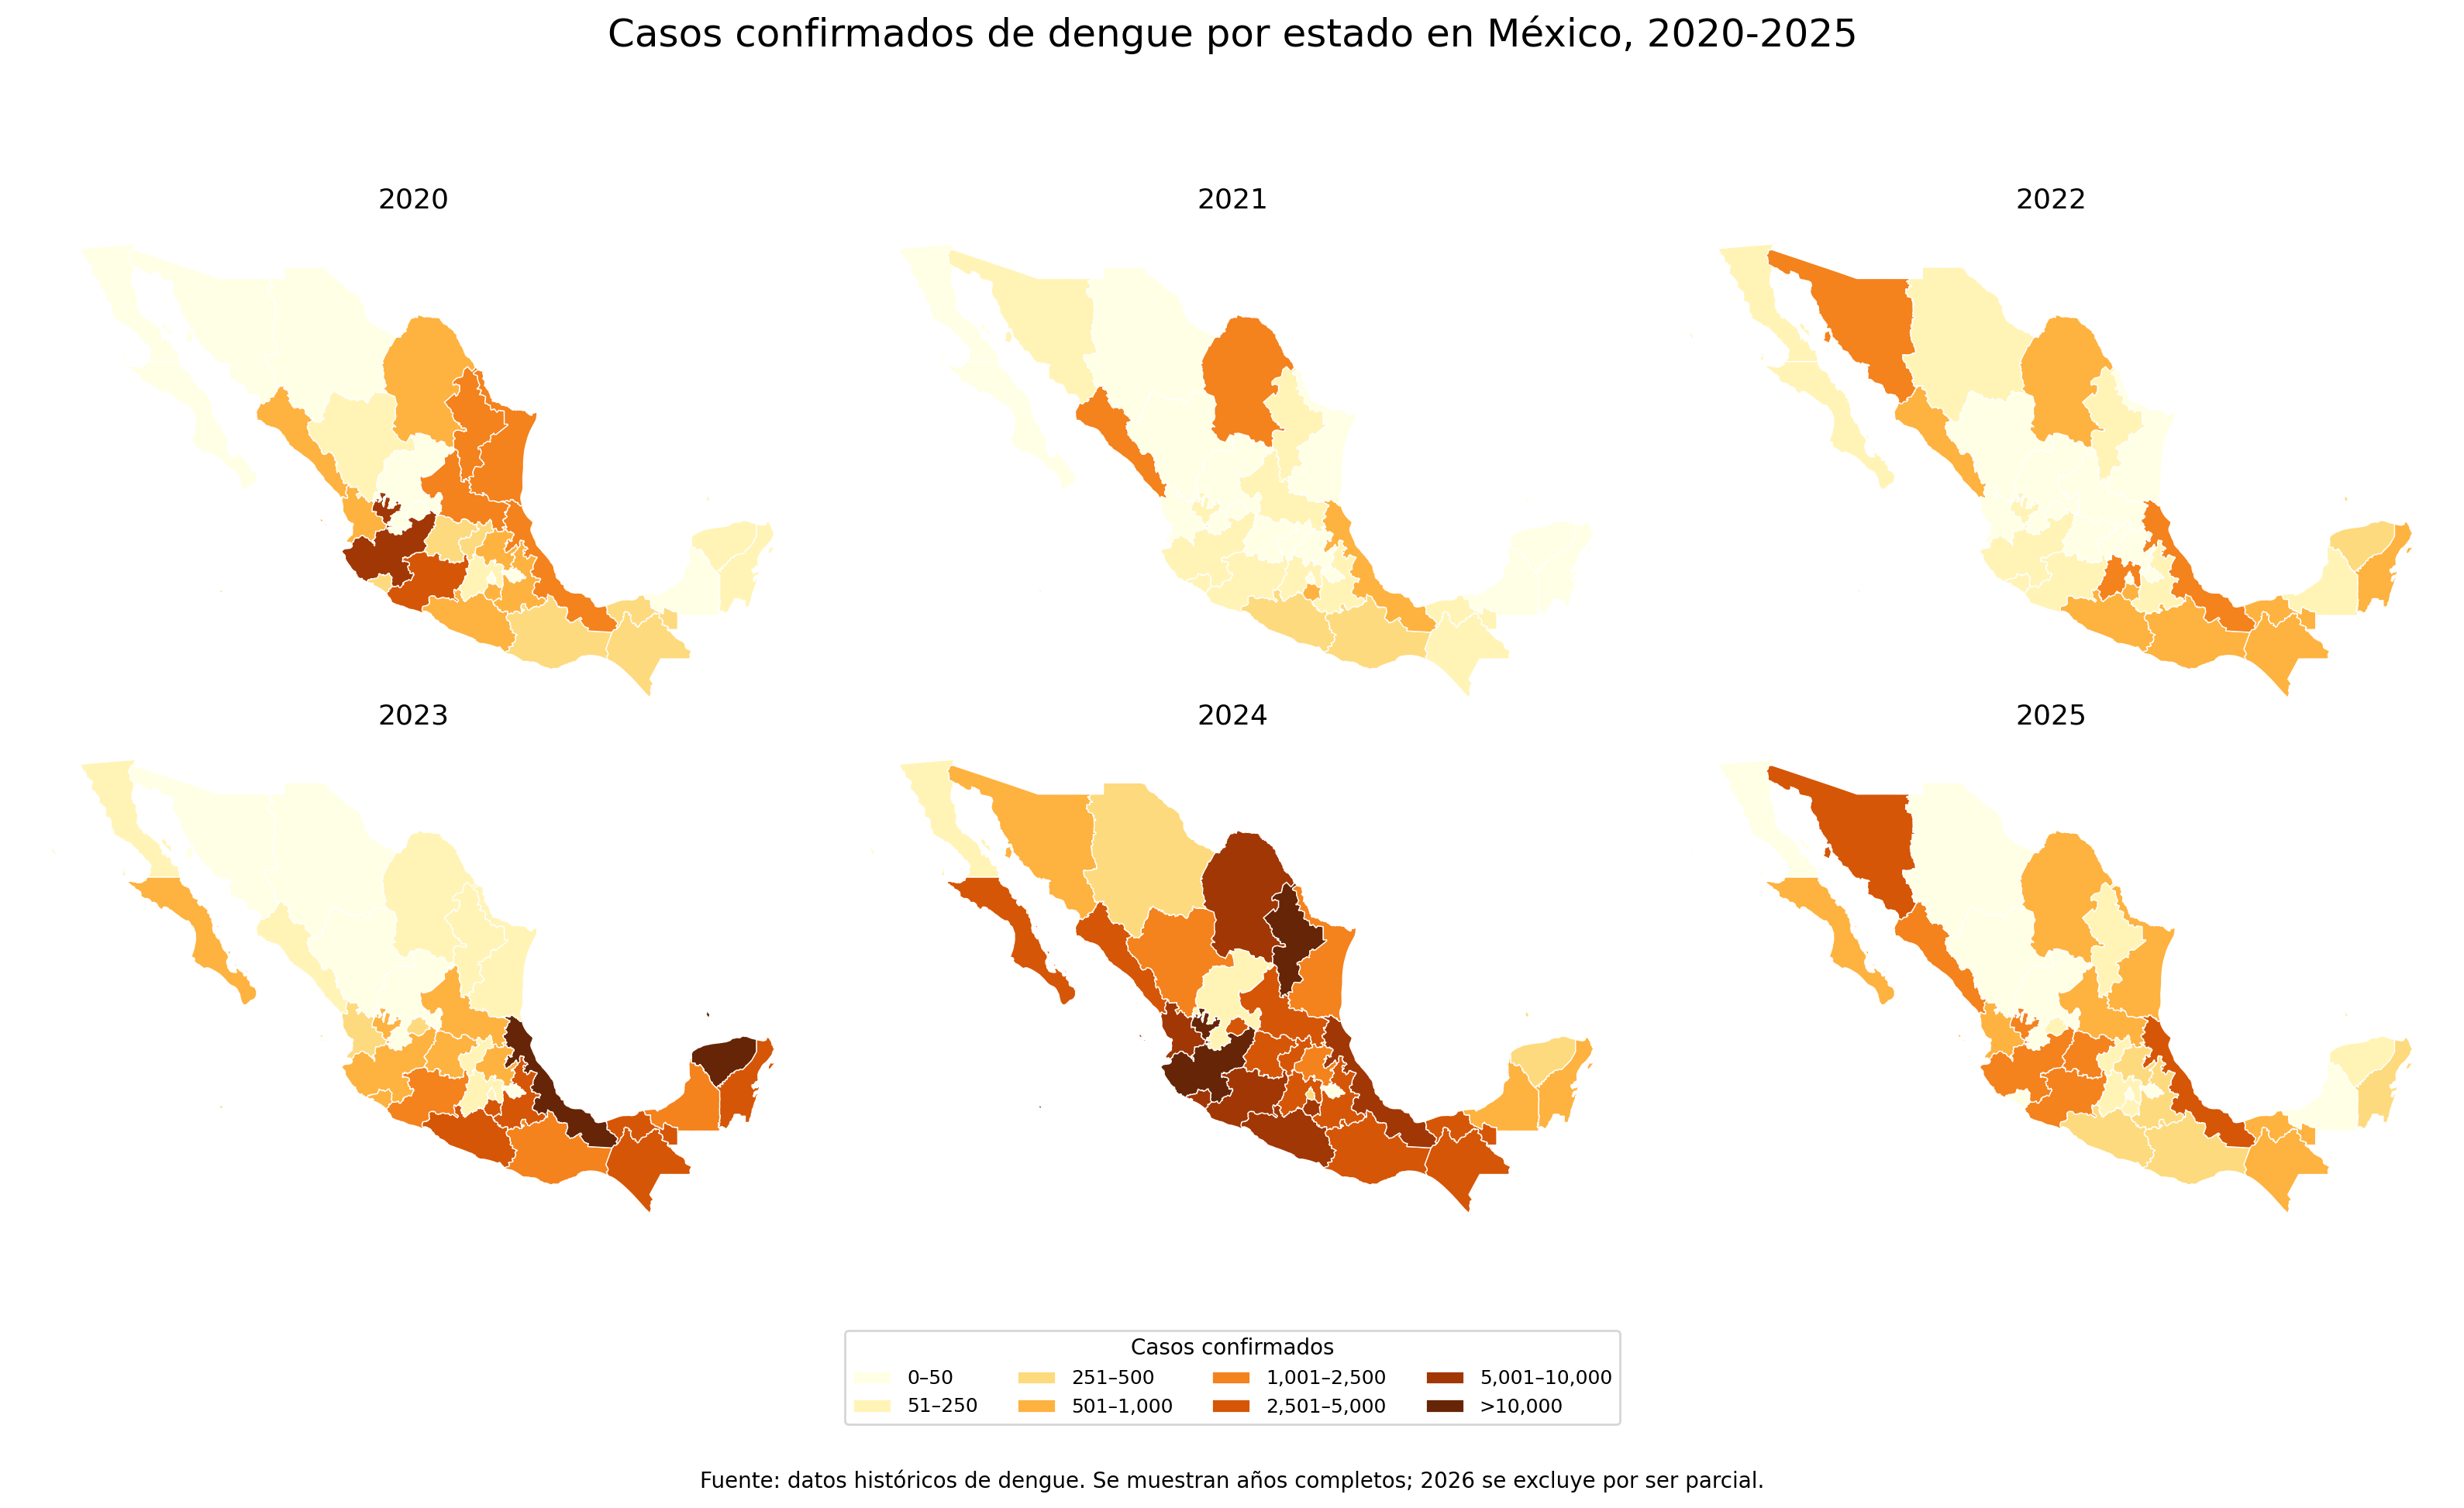

Figura guardada en: datos_dengue_historicos/figuras_mapas/fig_08_panel_mapas_casos_confirmados_estatales_2020_2025.png

Tabla guardada en:
/Users/juanalbertomartinez/Desktop/Dengue/datos_dengue_historicos/tablas_mapas/tabla_09_panel_casos_confirmados_estatales_2020_2025.csv


In [49]:
# ============================================================
# Celda 10. Panel de mapas de casos confirmados por estado, 2020-2025
# ============================================================

from matplotlib.patches import Patch
import matplotlib.patheffects as patheffects
import matplotlib.colors as mcolors

# ------------------------------------------------------------
# 1. Preparar datos 2020-2025
# ------------------------------------------------------------

anios_panel = [2020, 2021, 2022, 2023, 2024, 2025]

casos_panel = (
    incidencia_estado_anio
    .query("ANIO <= 2025")
    [["ANIO", "ESTADO", "CASOS_CONFIRMADOS"]]
    .copy()
)

# Asegurar panel completo estado-año
estados = sorted(gdf["ESTADO"].unique())

idx_completo = pd.MultiIndex.from_product(
    [anios_panel, estados],
    names=["ANIO", "ESTADO"]
)

casos_panel = (
    casos_panel
    .set_index(["ANIO", "ESTADO"])
    .reindex(idx_completo, fill_value=0)
    .reset_index()
)

print("Casos confirmados por estado-año:")
display(casos_panel.head())

print("\nTotales nacionales por año:")
display(
    casos_panel
    .groupby("ANIO")["CASOS_CONFIRMADOS"]
    .sum()
    .reset_index()
)

# ------------------------------------------------------------
# 2. Clases comunes de casos confirmados
# ------------------------------------------------------------

bins = [-0.1, 50, 250, 500, 1000, 2500, 5000, 10000, 25000]

labels = [
    "0–50",
    "51–250",
    "251–500",
    "501–1,000",
    "1,001–2,500",
    "2,501–5,000",
    "5,001–10,000",
    ">10,000"
]

casos_panel["CLASE_CASOS"] = pd.cut(
    casos_panel["CASOS_CONFIRMADOS"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Paleta fija en formato hexadecimal
cmap = plt.get_cmap("YlOrBr", len(labels))

color_dict = {
    label: mcolors.to_hex(cmap(i))
    for i, label in enumerate(labels)
}

# ------------------------------------------------------------
# 3. Preparar GeoDataFrame base
# ------------------------------------------------------------

gdf_base = gdf.copy()

gdf_base["ABREV"] = gdf_base["ESTADO"].map(abreviaturas)
gdf_base["label_pt"] = gdf_base.geometry.representative_point()

# ------------------------------------------------------------
# 4. Crear panel 2 x 3
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10),
    dpi=200
)

axes = axes.flatten()

for ax, anio in zip(axes, anios_panel):
    
    casos_anio = casos_panel[casos_panel["ANIO"] == anio].copy()
    
    gdf_anio = gdf_base.merge(
        casos_anio[["ESTADO", "CASOS_CONFIRMADOS", "CLASE_CASOS"]],
        on="ESTADO",
        how="left"
    )
    
    gdf_anio["COLOR"] = (
        gdf_anio["CLASE_CASOS"]
        .astype(str)
        .map(color_dict)
        .fillna("#f0f0f0")
    )
    
    gdf_anio.plot(
        color=gdf_anio["COLOR"].tolist(),
        linewidth=0.5,
        edgecolor="white",
        ax=ax
    )
    
    ax.set_title(f"{anio}", fontsize=13)
    ax.axis("off")

# ------------------------------------------------------------
# 5. Leyenda común y ajustes finales
# ------------------------------------------------------------

legend_elements = [
    Patch(
        facecolor=color_dict[label],
        edgecolor="white",
        label=label
    )
    for label in labels
]

fig.legend(
    handles=legend_elements,
    title="Casos confirmados",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.055),
    ncol=4,
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

fig.suptitle(
    "Casos confirmados de dengue por estado en México, 2020-2025",
    fontsize=18,
    y=0.97
)

fig.text(
    0.5,
    0.02,
    "Fuente: datos históricos de dengue. "
    "Se muestran años completos; 2026 se excluye por ser parcial.",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.12, 1, 0.94])

fig_path = FIG_DIR / "fig_08_panel_mapas_casos_confirmados_estatales_2020_2025.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {fig_path}")

# ------------------------------------------------------------
# 6. Guardar tabla usada para el panel
# ------------------------------------------------------------

casos_panel.to_csv(
    TABLE_DIR / "tabla_09_panel_casos_confirmados_estatales_2020_2025.csv",
    index=False,
    encoding="utf-8"
)

print("\nTabla guardada en:")
print((TABLE_DIR / "tabla_09_panel_casos_confirmados_estatales_2020_2025.csv").resolve())

### Evolución espacial de los casos confirmados, 2020--2025

El panel muestra la distribución estatal de los casos confirmados de dengue en México durante los años completos del periodo de estudio. Se observa una baja carga nacional en 2021, seguida por un aumento gradual en 2022 y un cambio espacial importante en 2023, cuando la mayor concentración de casos se ubicó en el sureste y la península de Yucatán. En 2024 se aprecia la mayor expansión territorial y la mayor carga absoluta del periodo, con altos conteos en estados del occidente, noreste, centro y sur del país. En 2025 la carga disminuye respecto a 2024, aunque persisten focos importantes en algunos estados del norte, occidente y Golfo de México.

Este panel debe interpretarse junto con el panel de incidencia, ya que los conteos absolutos reflejan la carga total de casos, mientras que la incidencia permite ajustar por el tamaño poblacional de cada entidad.